In [1]:
import os
import pyvista as pv
import matplotlib.pyplot as plt
from glob import glob
from natsort import natsorted
os.environ['PYVISTA_OFF_SCREEN'] = 'true'
pv.set_jupyter_backend('client')# pv.start_xvfb()                              
pv.global_theme.trame.server_proxy_enabled = True
pv.global_theme.trame.server_proxy_prefix = "/proxy/"

In [2]:
base_pth = "./128"
out_pth = os.path.join(base_pth, "output_drainage")
out_sim = glob(out_pth + "/*.vtk")
out_sim = natsorted(out_sim)
print(len(out_sim))

251


In [3]:
idx = 25
print(out_sim[idx])
sample = pv.read(out_sim[idx])
print(sample)

./128/output_drainage/data_0025000.vtk
ImageData (0x14d4148e7940)
  N Cells:      2286144
  N Points:     2338705
  X Bounds:     0.000e+00, 1.440e+02
  Y Bounds:     0.000e+00, 1.260e+02
  Z Bounds:     0.000e+00, 1.260e+02
  Dimensions:   145, 127, 127
  Spacing:      1.000e+00, 1.000e+00, 1.000e+00
  N Arrays:     9


In [4]:
print(sample.array_names)        # list all 17 field names 
print(sample['rho_water'].shape)

['rho', 'ux', 'uy', 'uz', 'rho_water', 'rho_air', 'p_air', 'p_water', 'flag']
(2286144,)


In [5]:
def get_phase(sample, nwp_key, wp_key, target="nwp"):
    nx, ny, nz = sample.dimensions
    nwp = sample[nwp_key].reshape(nx-1, ny-1, nz-1, order='F')
    wp = sample[wp_key].reshape(nx-1, ny-1, nz-1, order='F')
    out = nwp > wp if target == "nwp" else nwp < wp
    return out

def get_rock(sample):
    nx, ny, nz = sample.dimensions
    out = sample['flag'].reshape(nx-1, ny-1, nz-1, order='F')
    return out

In [6]:
def plot_slice(sample, z=100):
    nx, ny, nz = sample.dimensions
    rho_air  = sample["rho_air"].reshape(nx-1, ny-1, nz-1, order="F")
    rho_water = sample["rho_water"].reshape(nx-1, ny-1, nz-1, order="F")
    phase = get_phase(sample, "rho_air", "rho_water", target="nwp")
    rock  = get_rock(sample)

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    titles = ["Phase (NWP threshold)", "rho_air", "rho_water", "Rock"]
    data   = [phase[:, :, z], rho_air[:, :, z], rho_water[:, :, z], rock[:, :, z]]

    for ax, d, title in zip(axes, data, titles):
        im = ax.imshow(d, origin="lower")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

plotting for sample at ./128/output_drainage/data_0000000.vtk


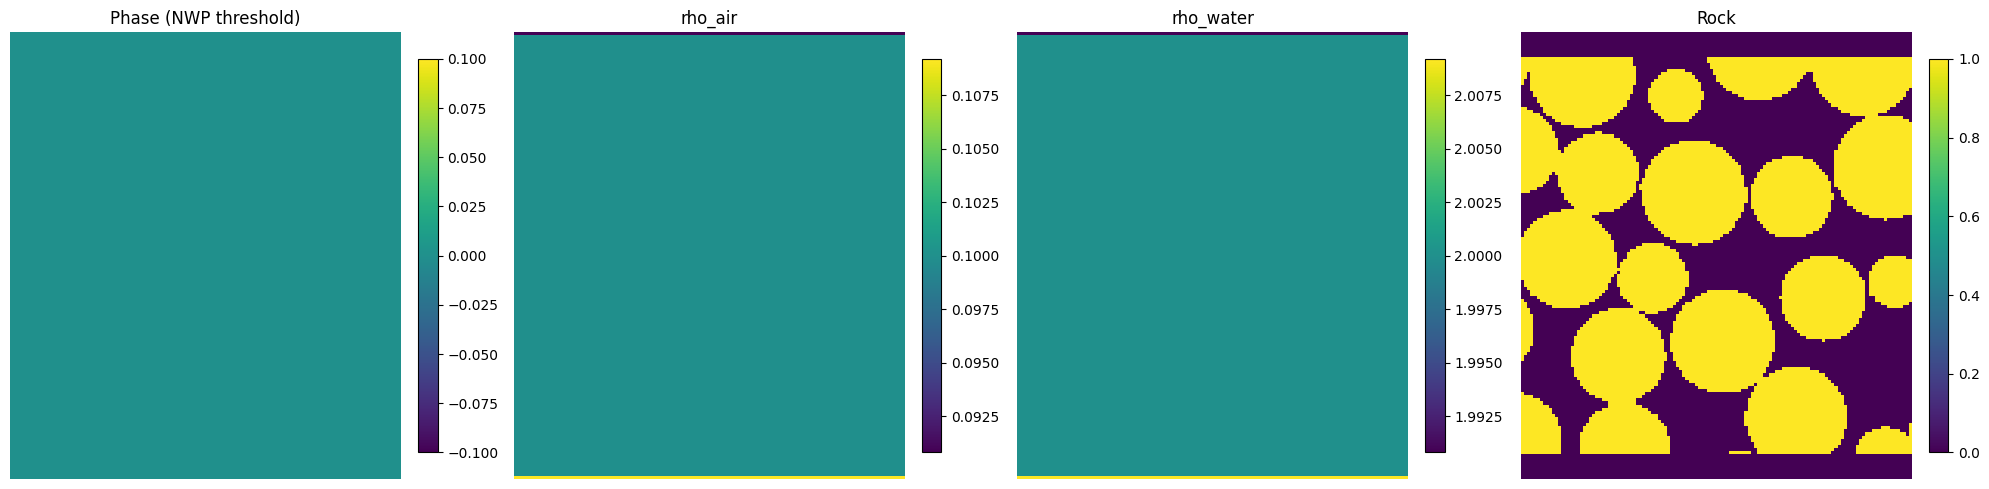

plotting for sample at ./128/output_drainage/data_0001000.vtk


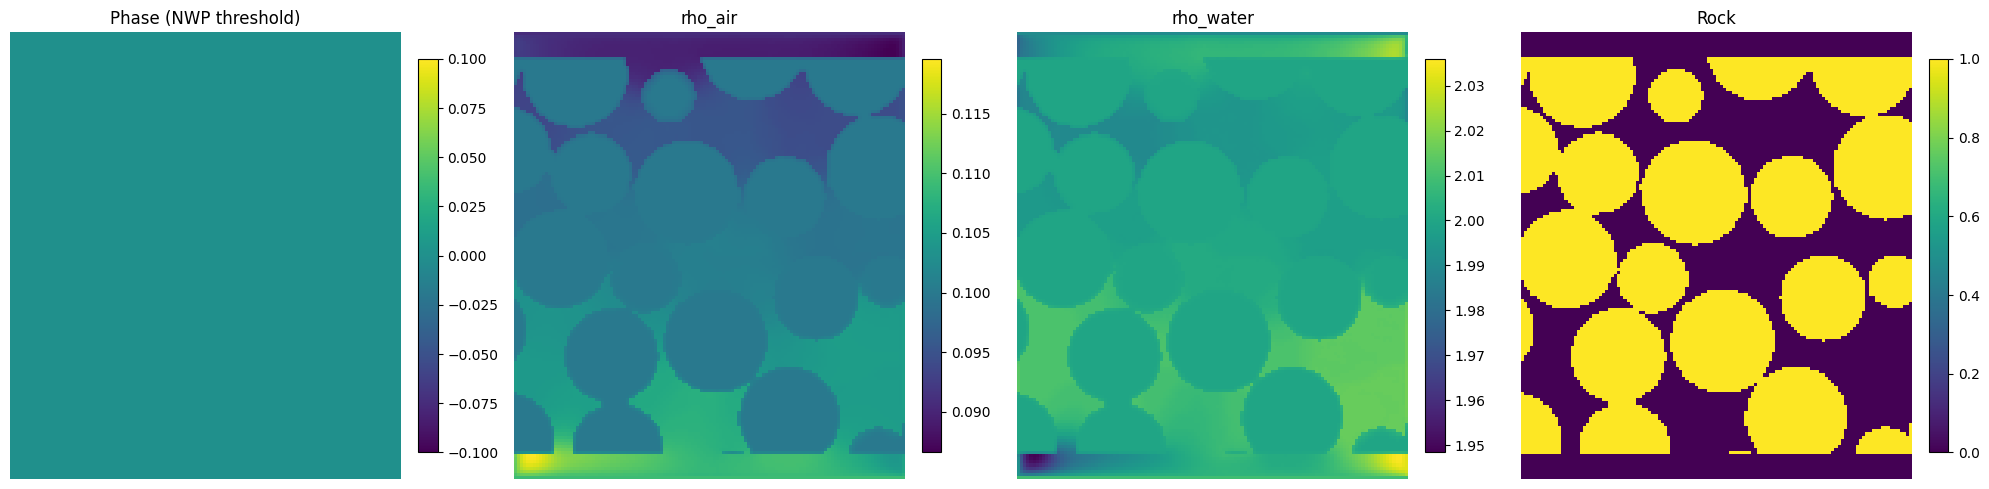

plotting for sample at ./128/output_drainage/data_0002000.vtk


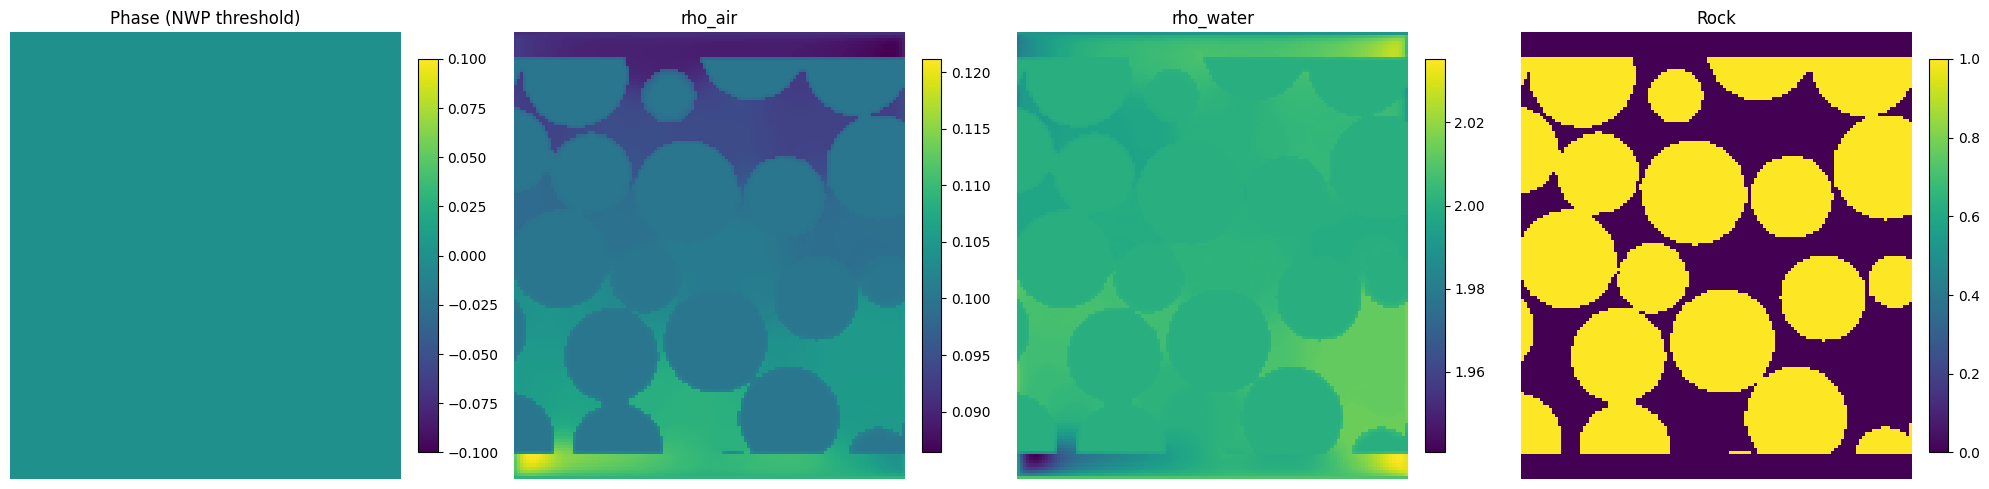

plotting for sample at ./128/output_drainage/data_0003000.vtk


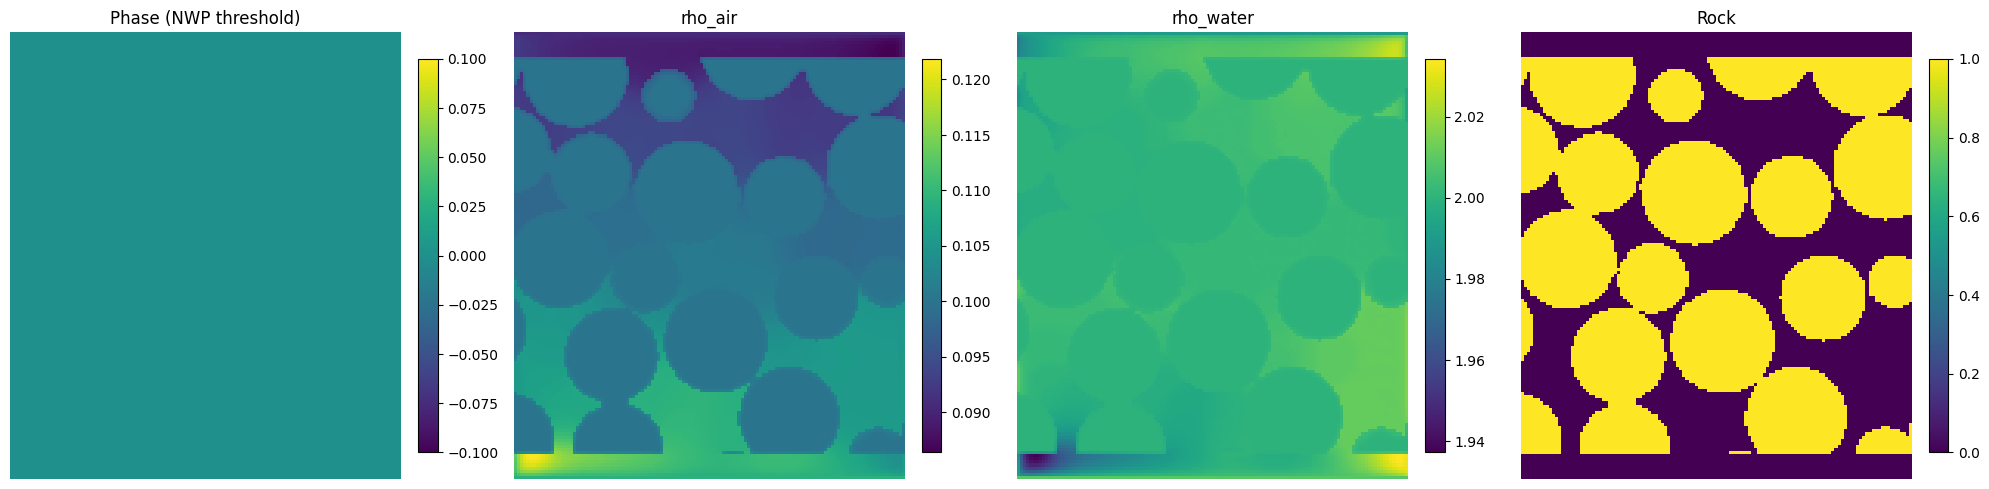

plotting for sample at ./128/output_drainage/data_0004000.vtk


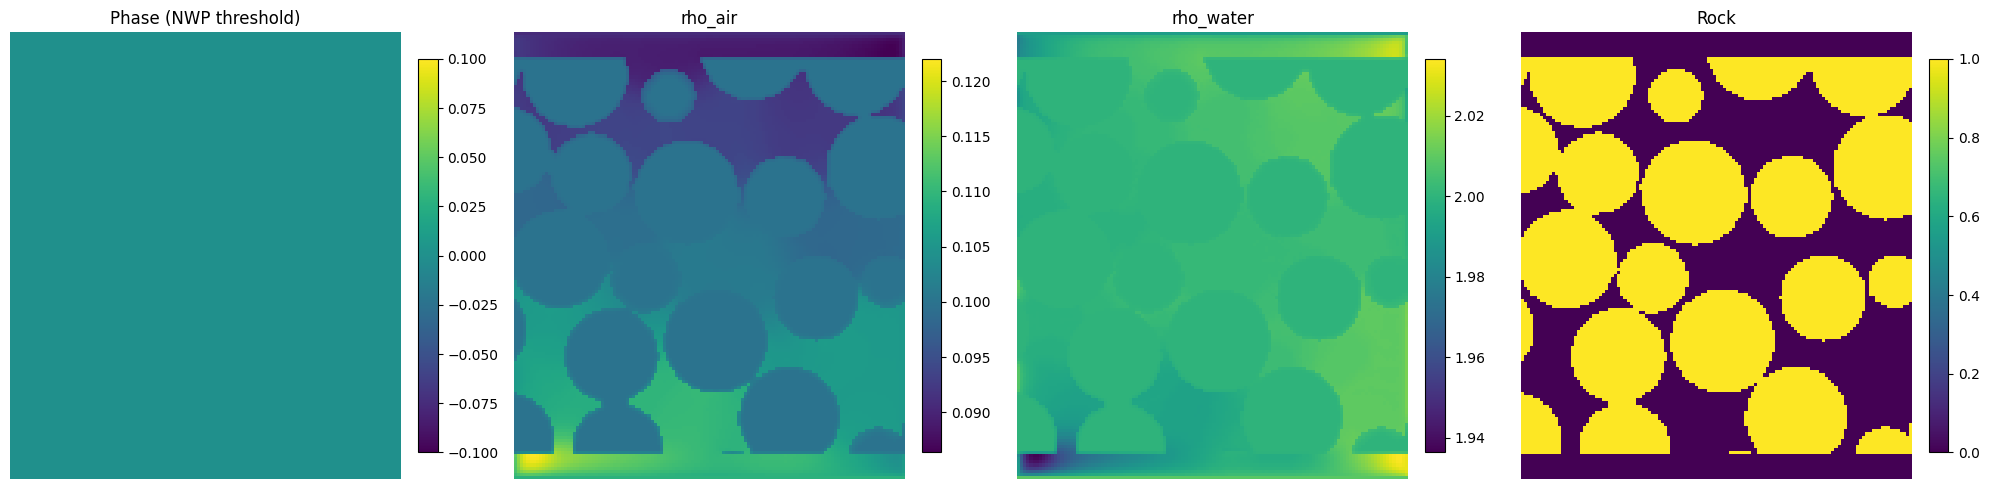

plotting for sample at ./128/output_drainage/data_0005000.vtk


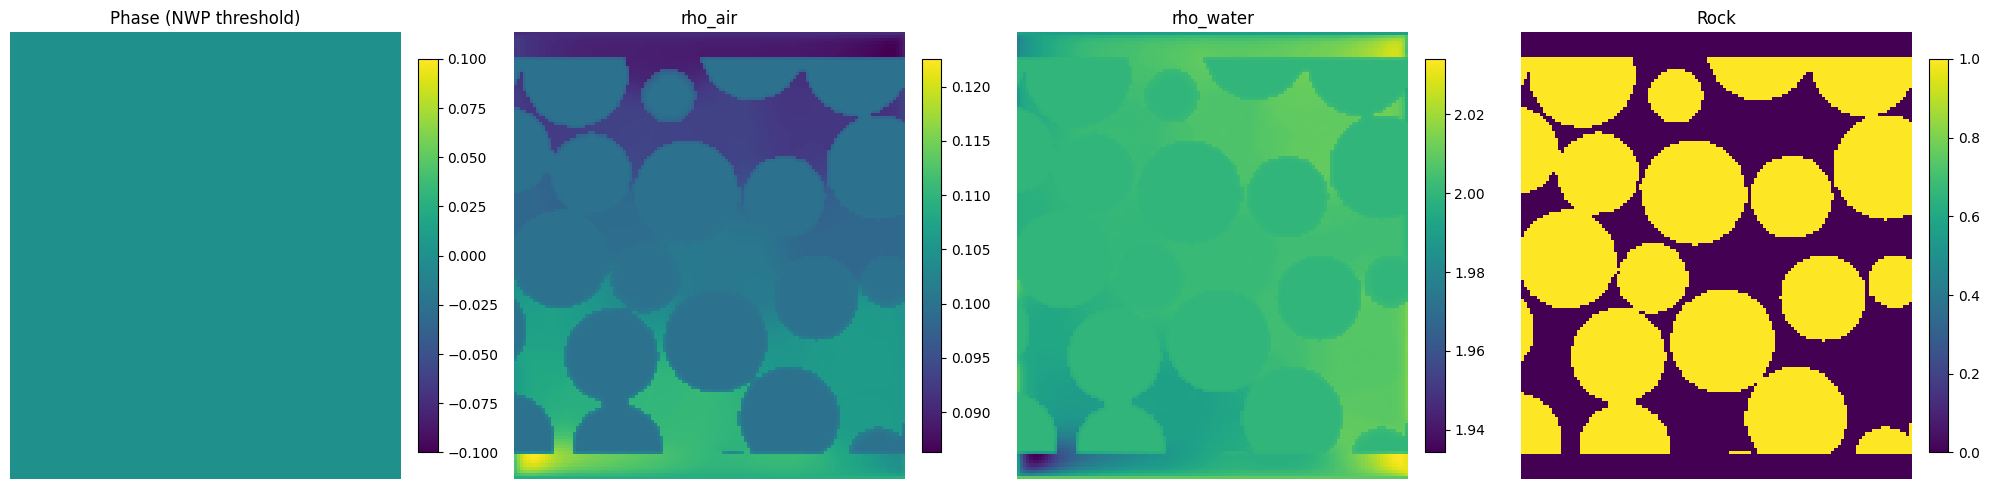

plotting for sample at ./128/output_drainage/data_0006000.vtk


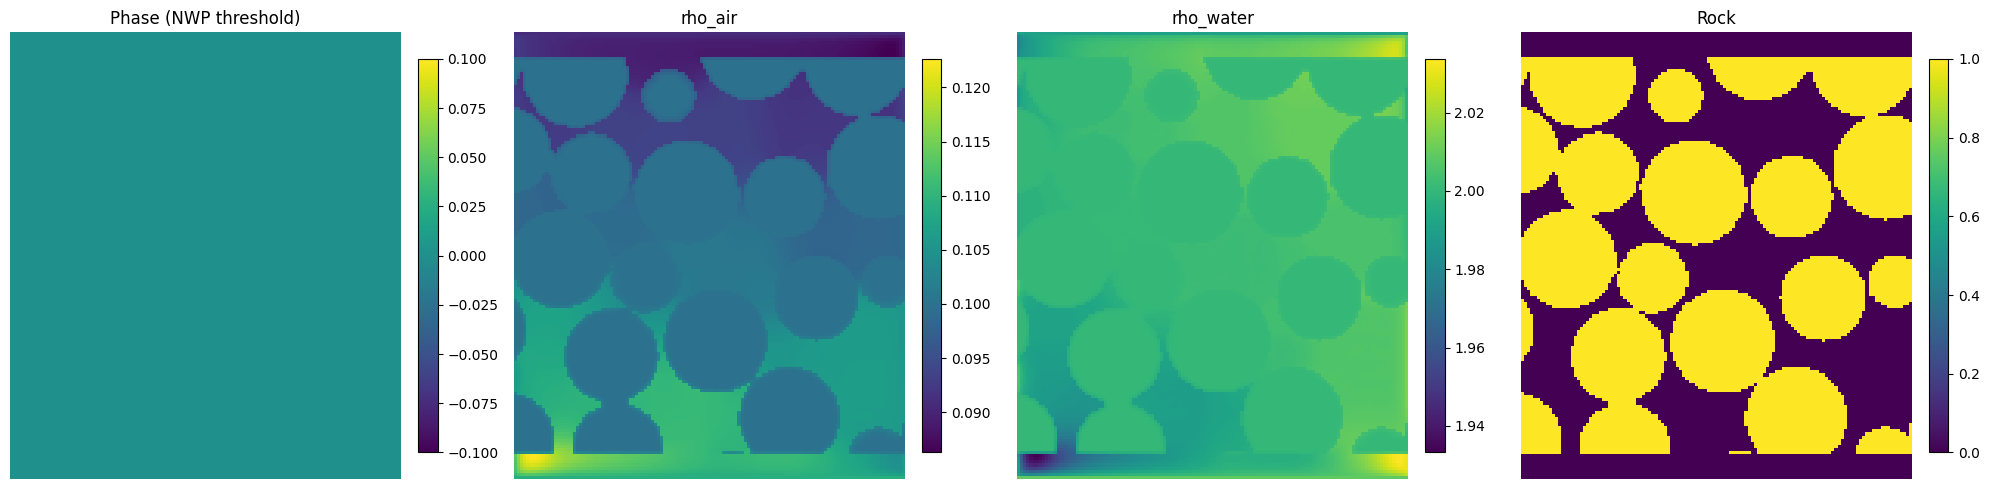

plotting for sample at ./128/output_drainage/data_0007000.vtk


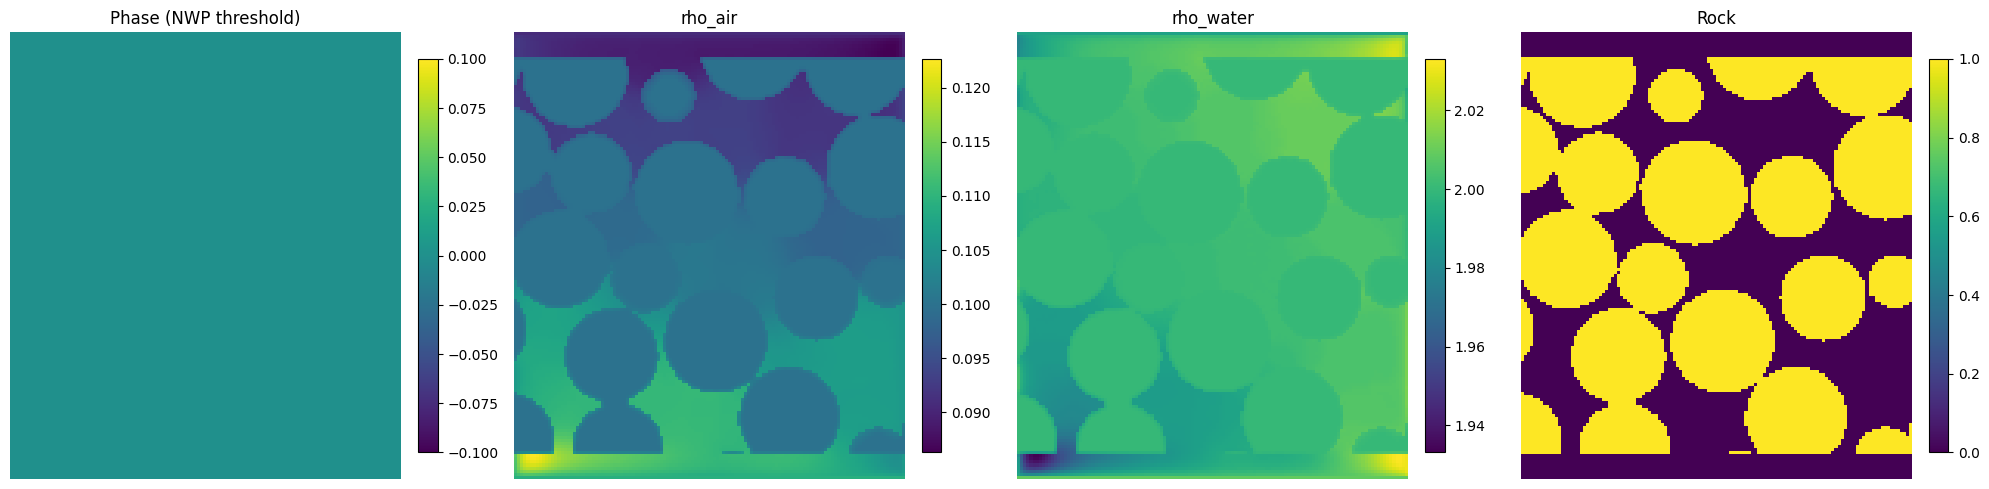

plotting for sample at ./128/output_drainage/data_0008000.vtk


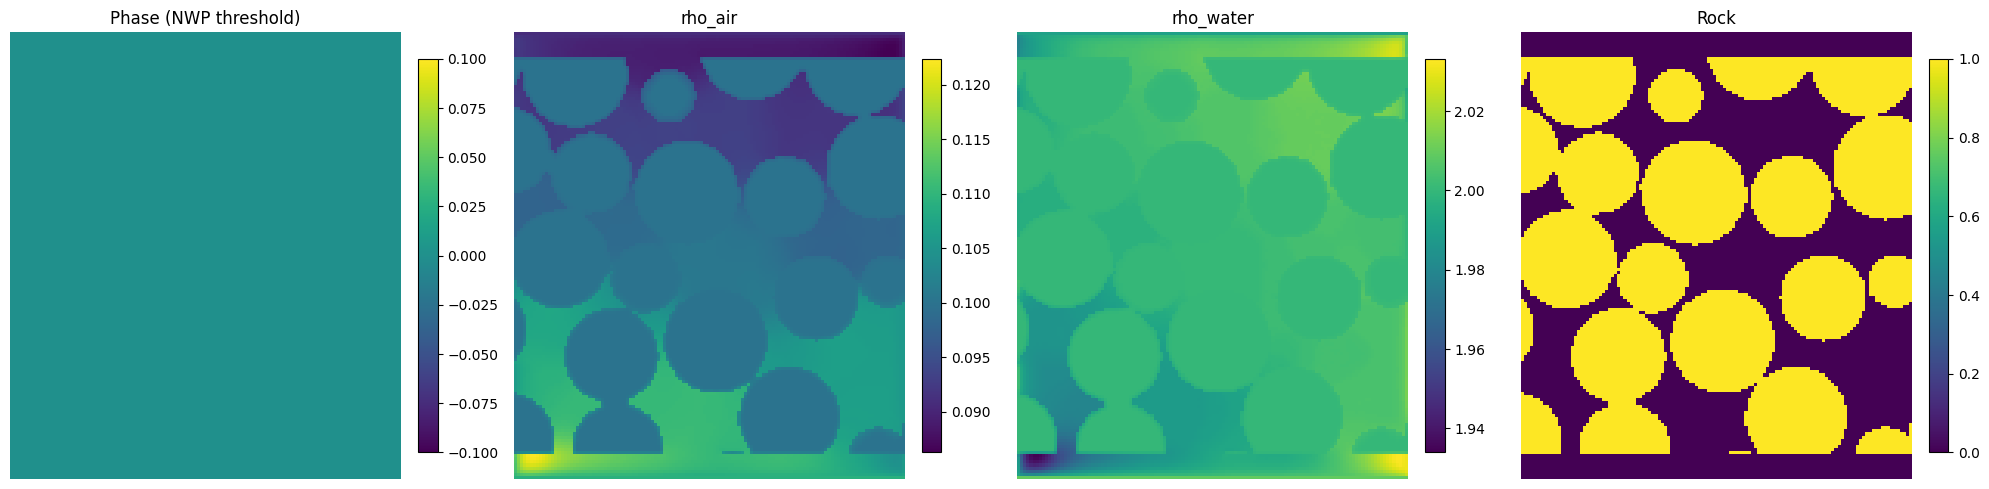

plotting for sample at ./128/output_drainage/data_0009000.vtk


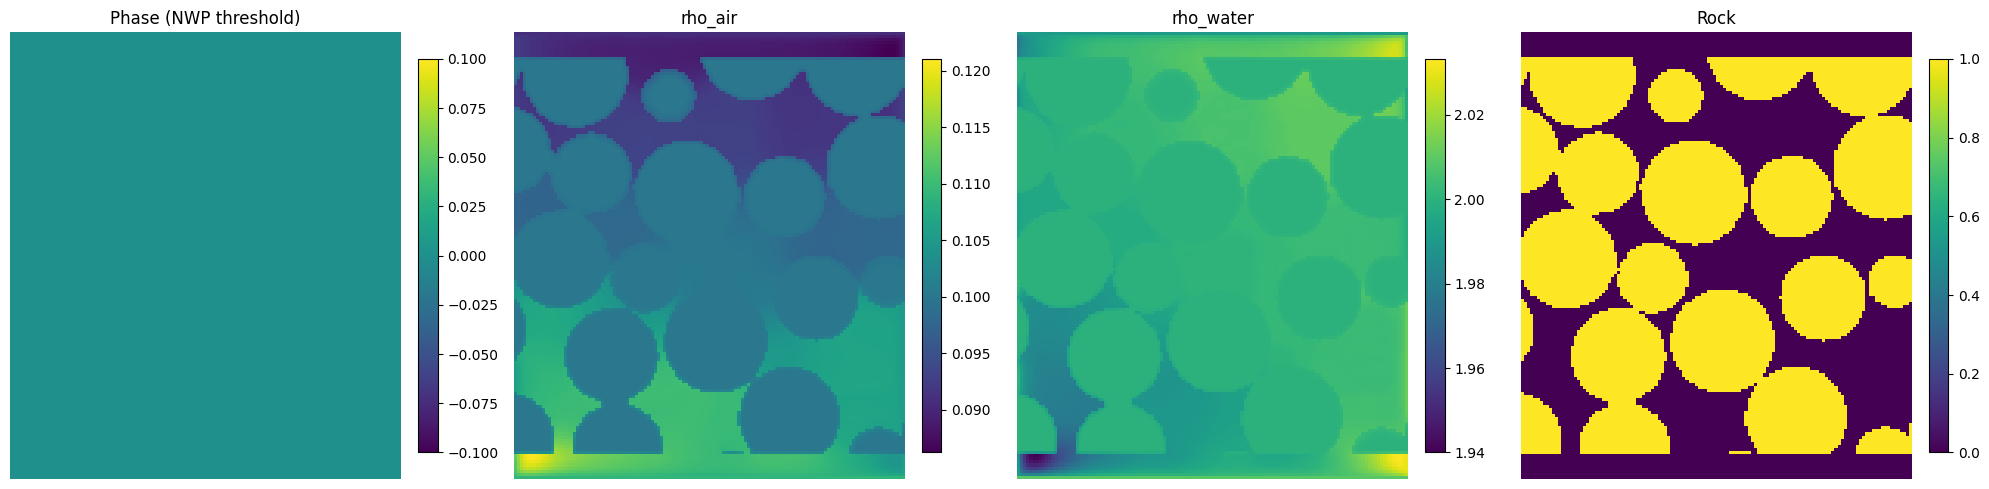

plotting for sample at ./128/output_drainage/data_0010000.vtk


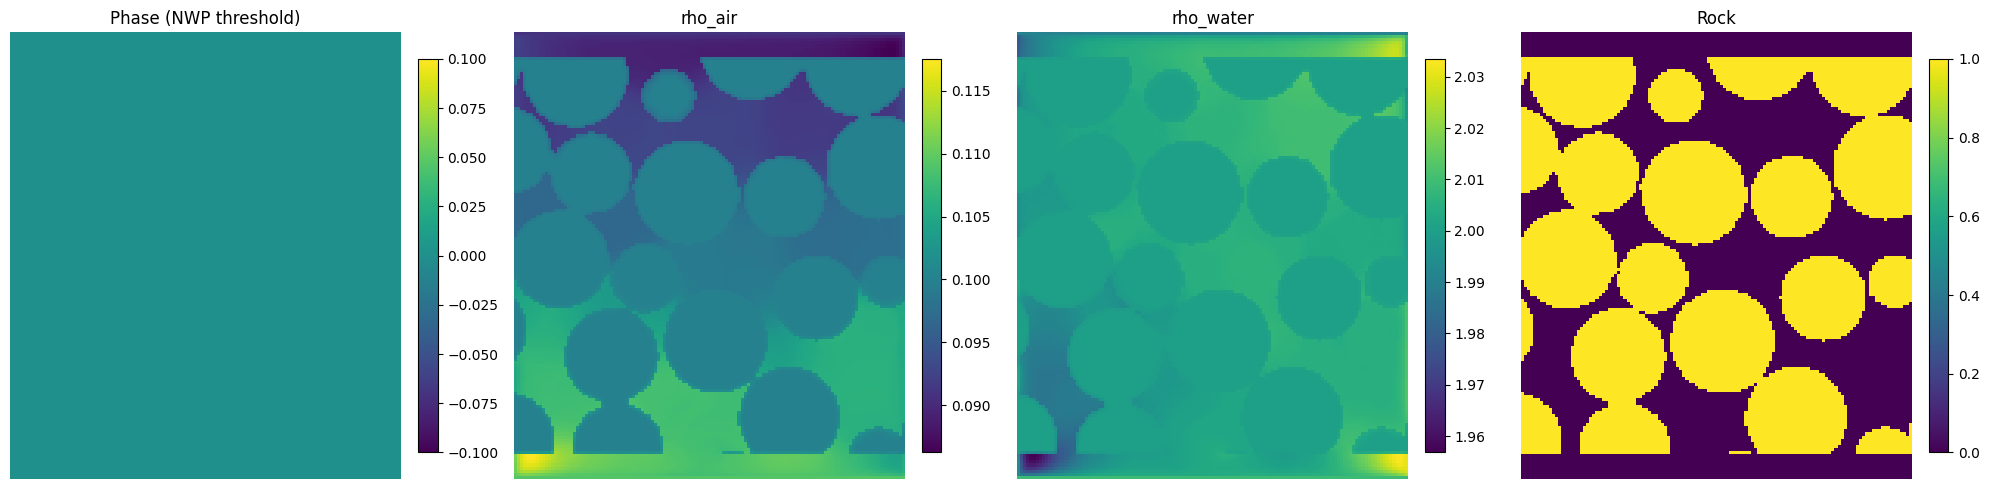

plotting for sample at ./128/output_drainage/data_0011000.vtk


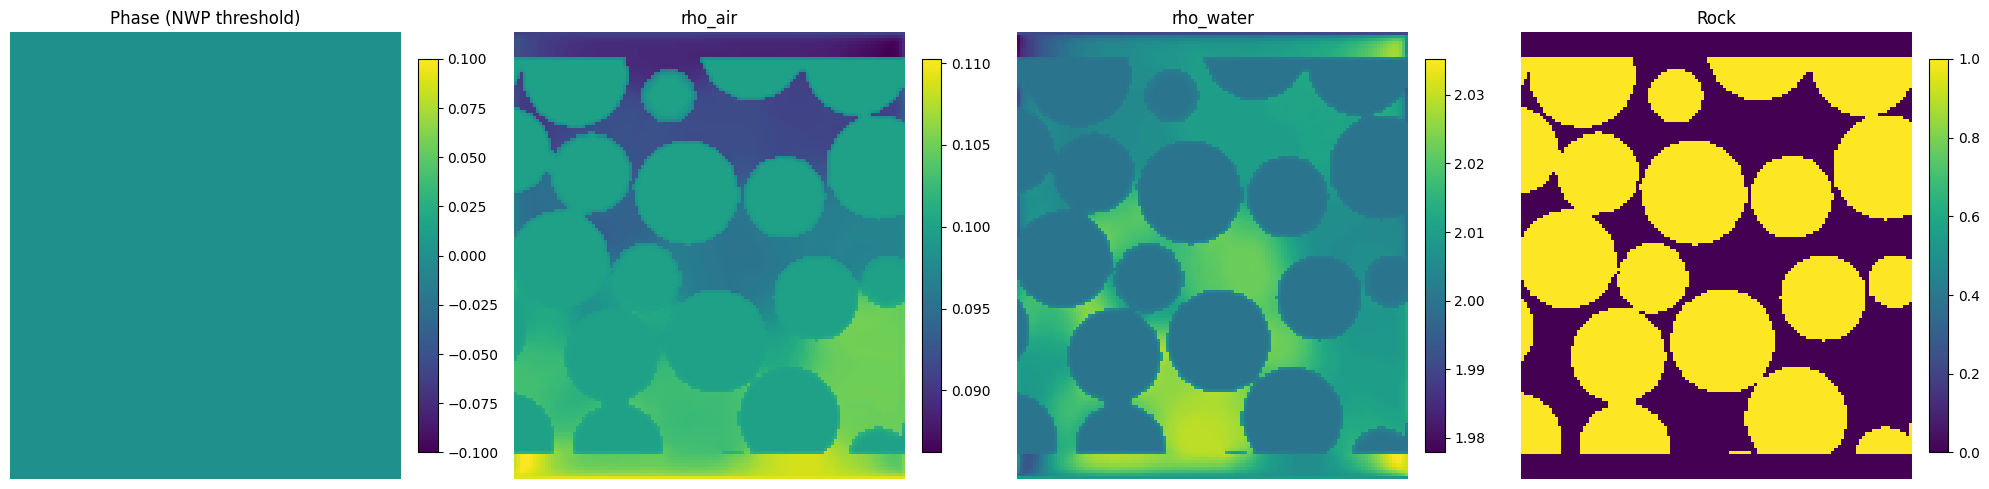

plotting for sample at ./128/output_drainage/data_0012000.vtk


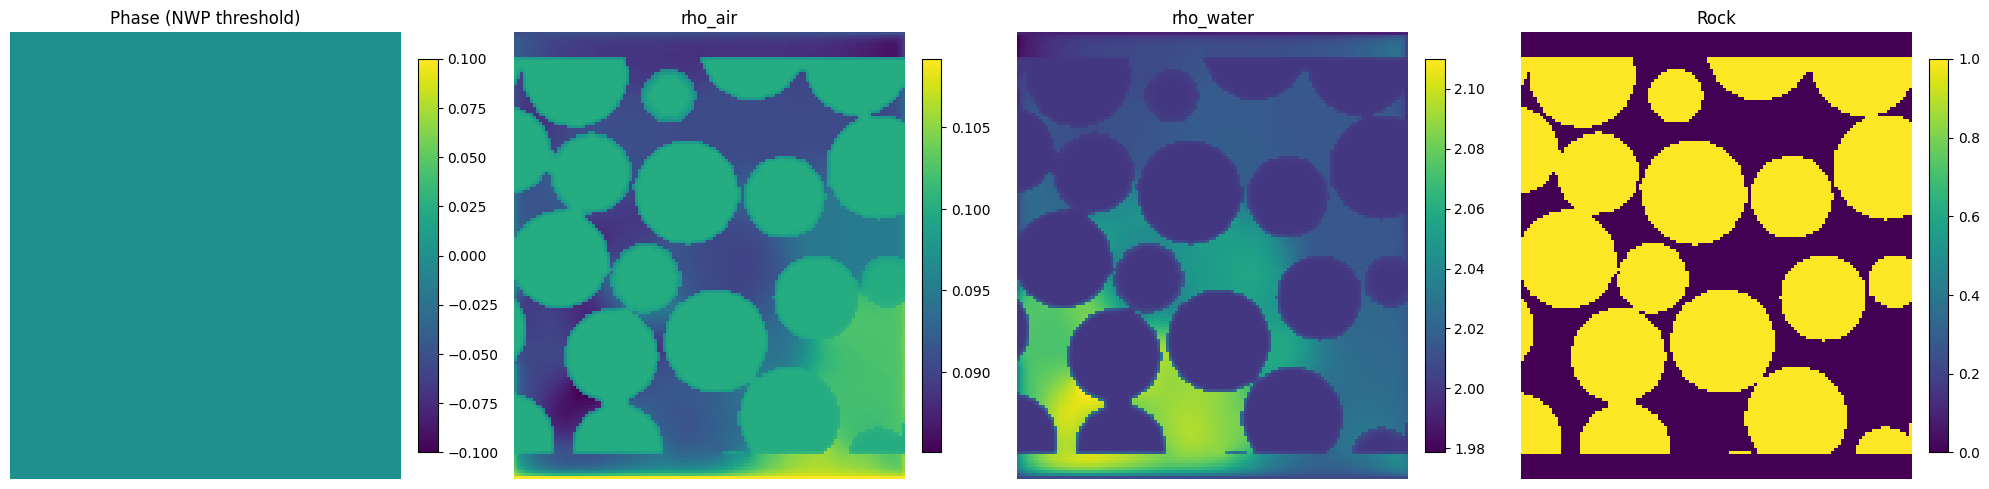

plotting for sample at ./128/output_drainage/data_0013000.vtk


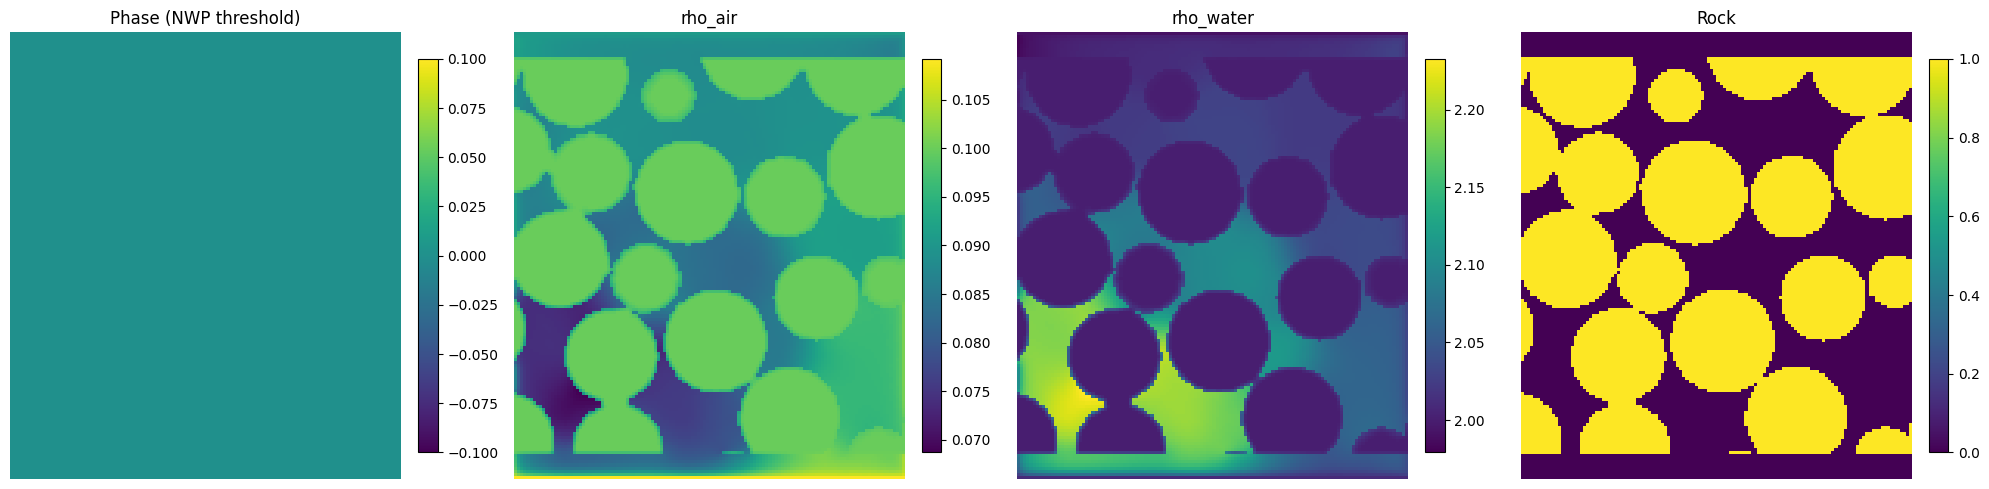

plotting for sample at ./128/output_drainage/data_0014000.vtk


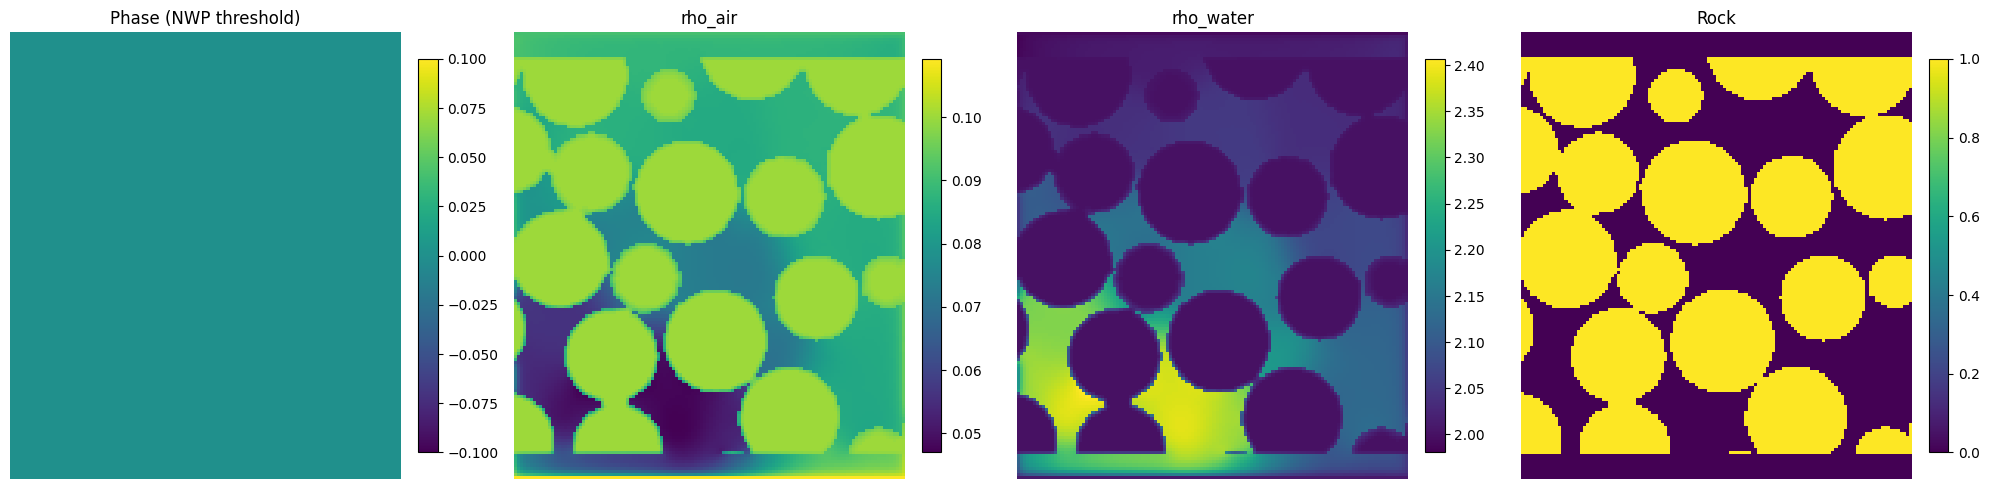

plotting for sample at ./128/output_drainage/data_0015000.vtk


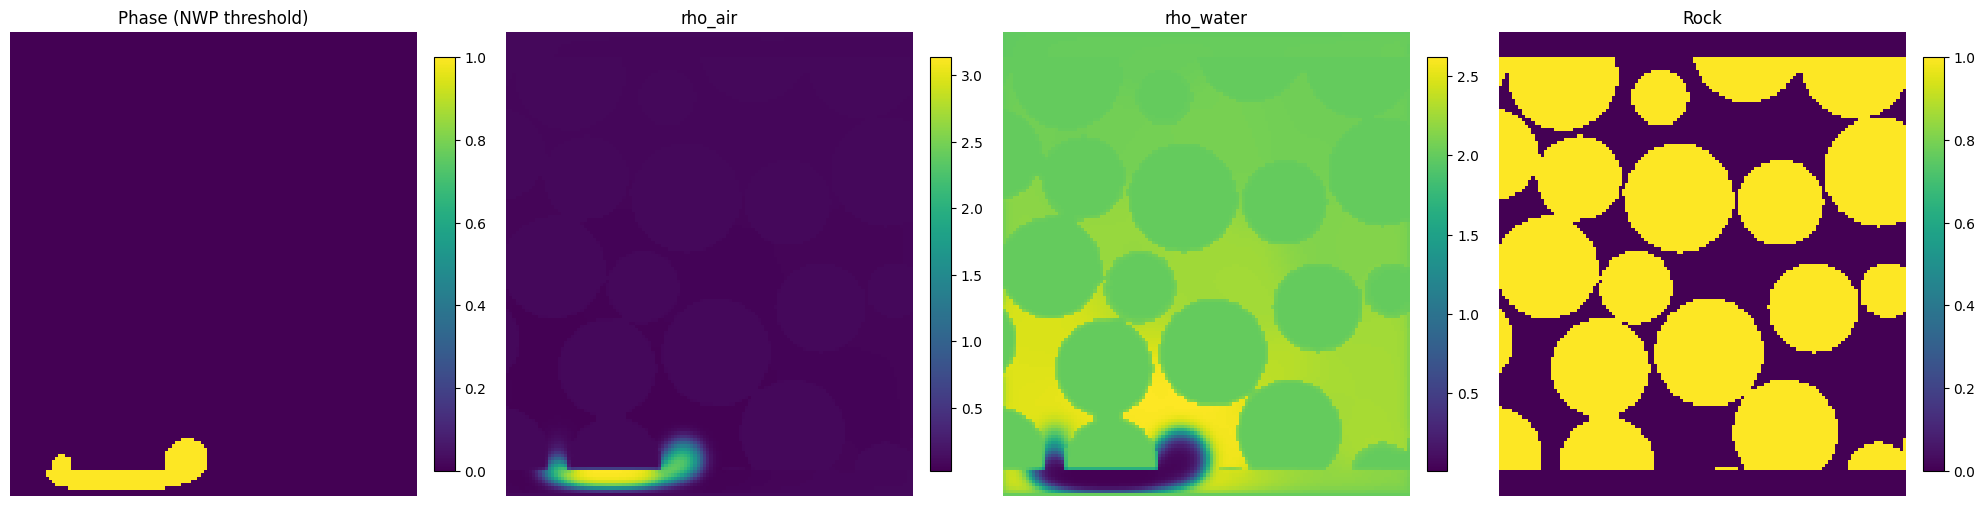

plotting for sample at ./128/output_drainage/data_0016000.vtk


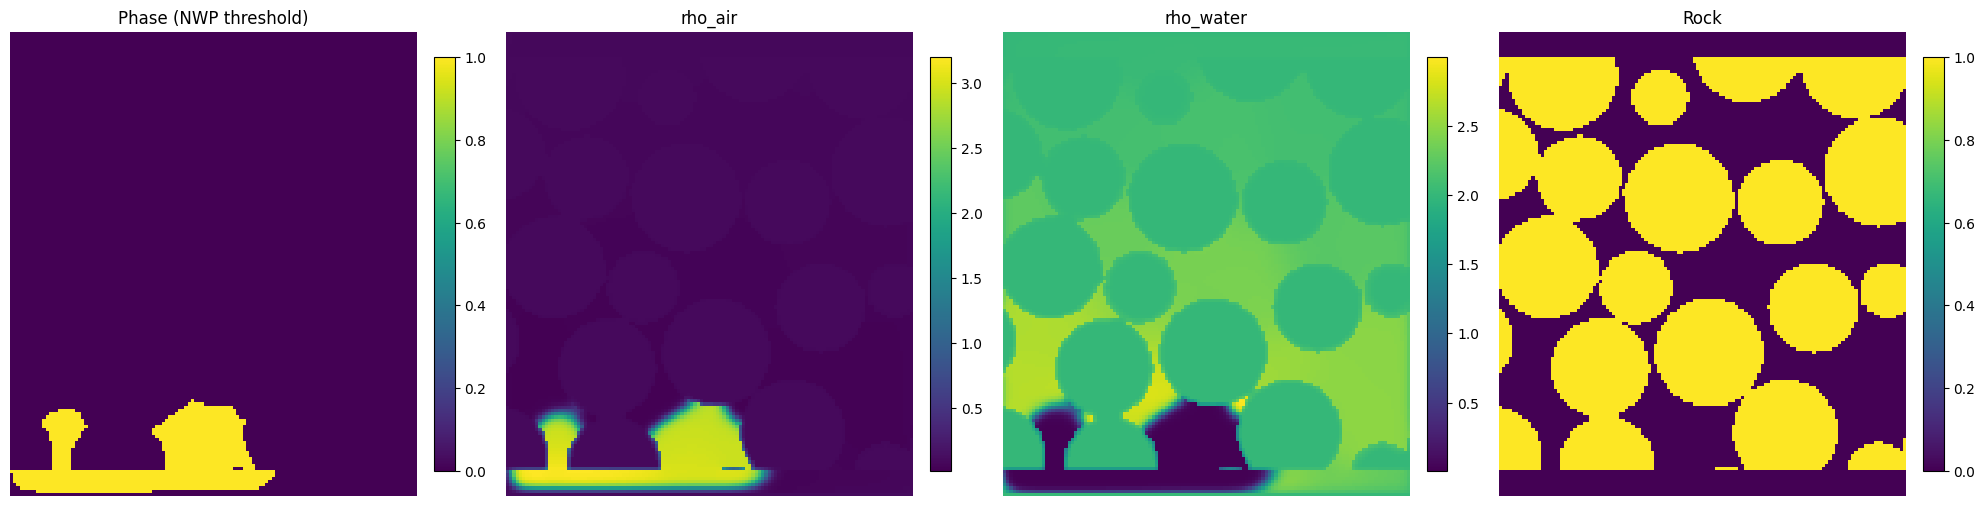

plotting for sample at ./128/output_drainage/data_0017000.vtk


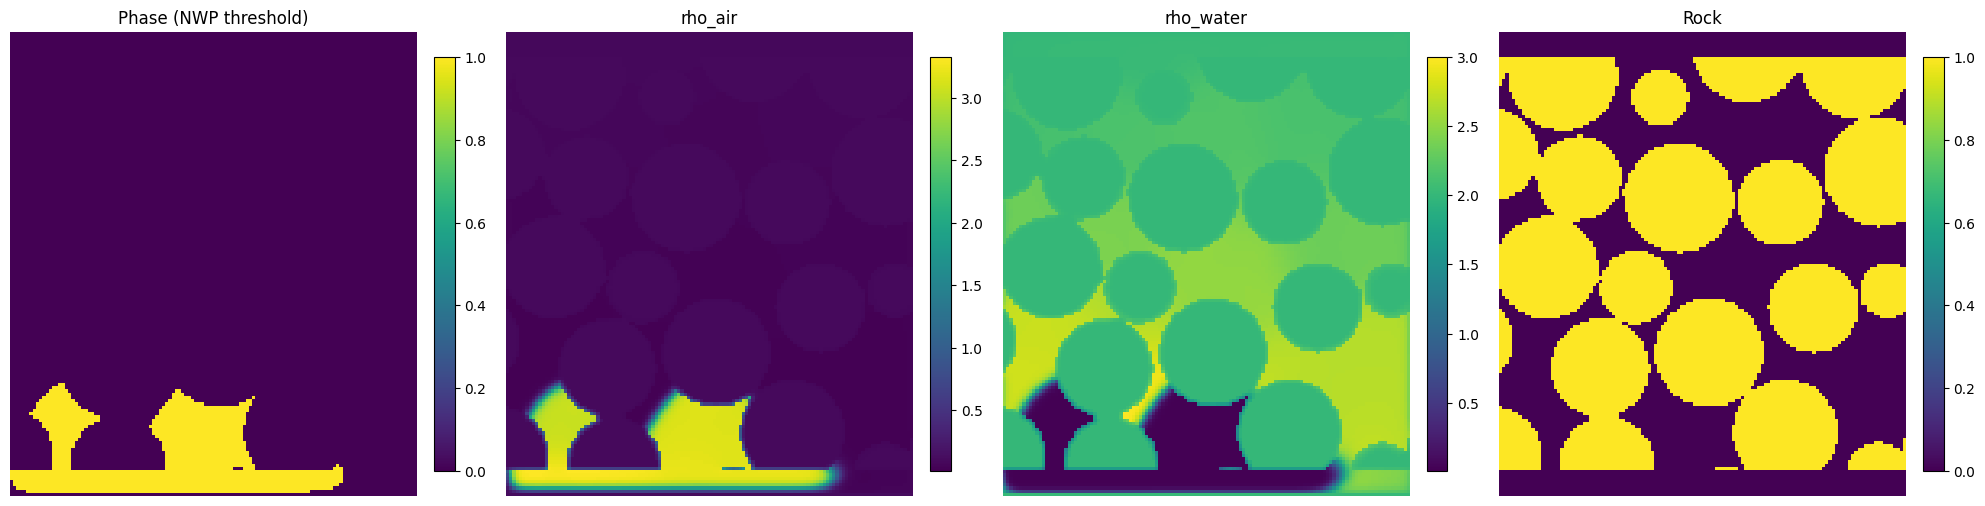

plotting for sample at ./128/output_drainage/data_0018000.vtk


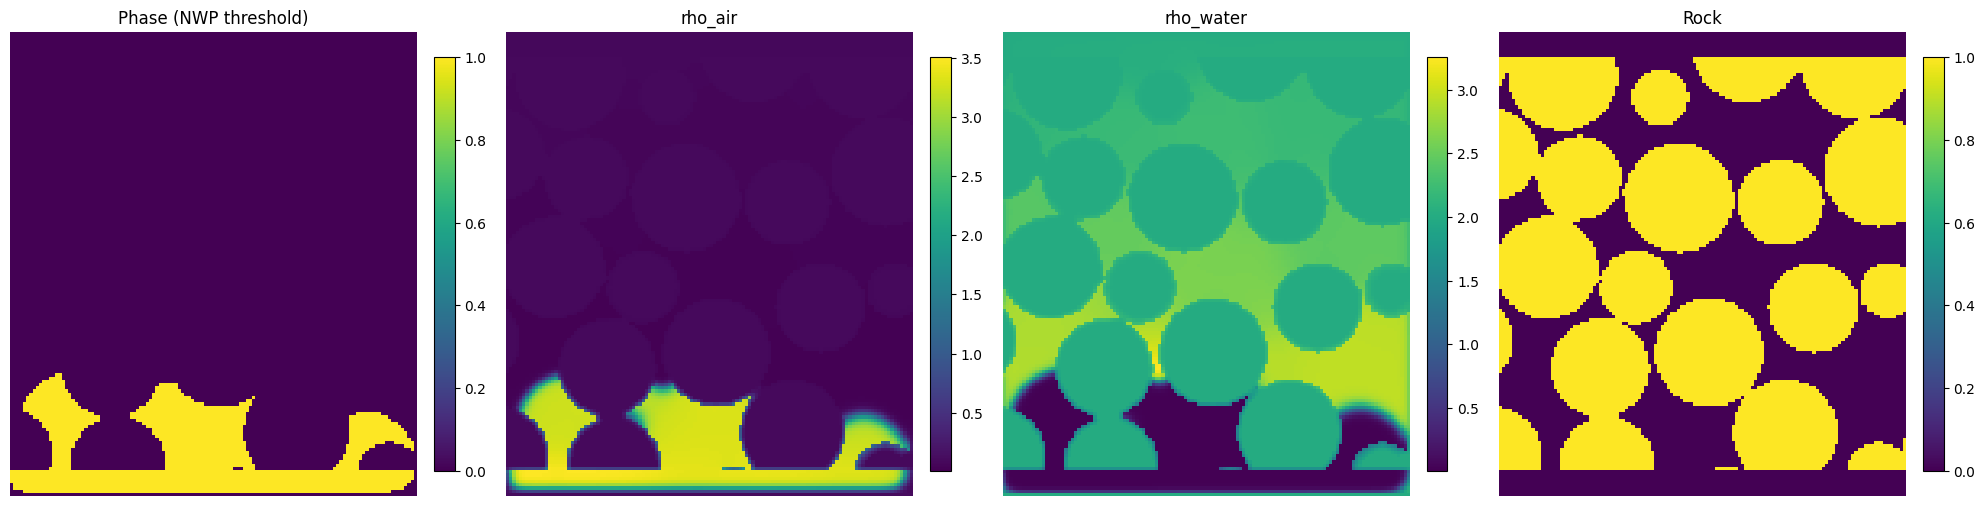

plotting for sample at ./128/output_drainage/data_0019000.vtk


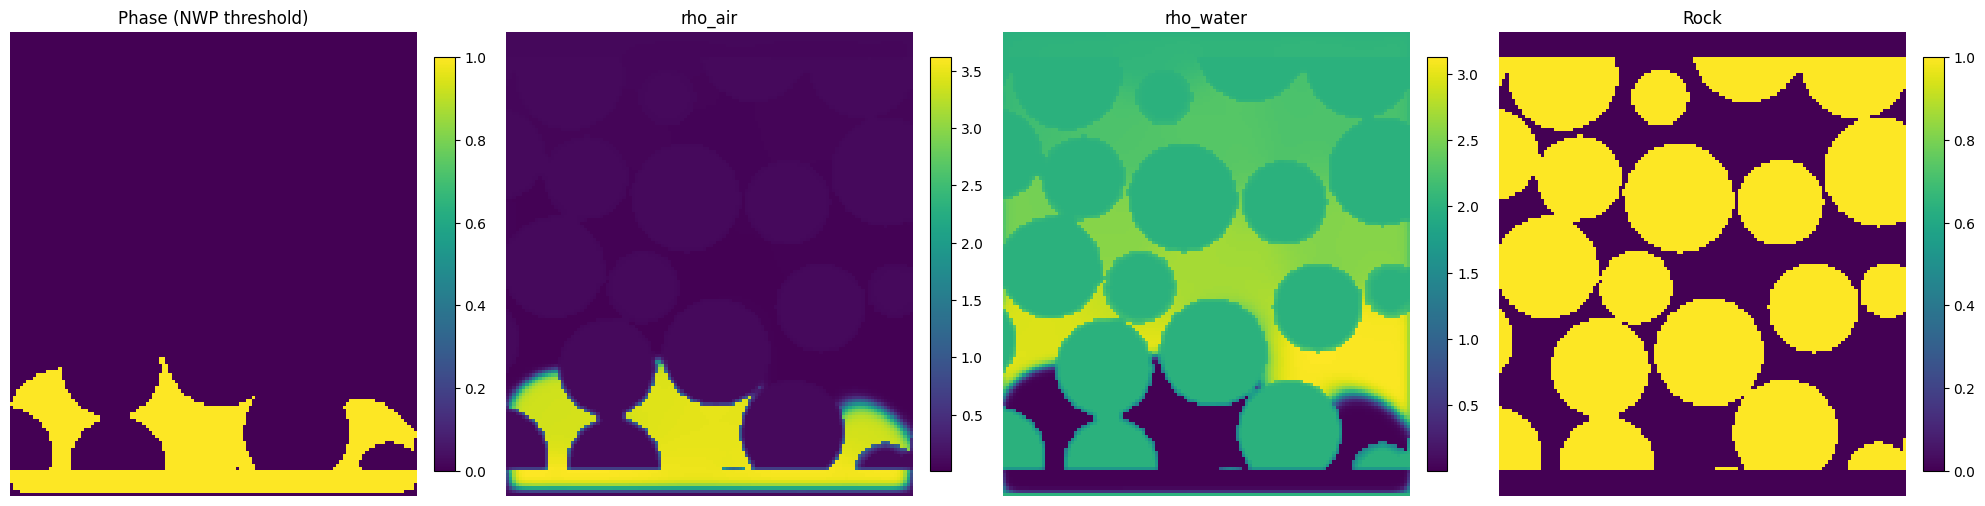

plotting for sample at ./128/output_drainage/data_0020000.vtk


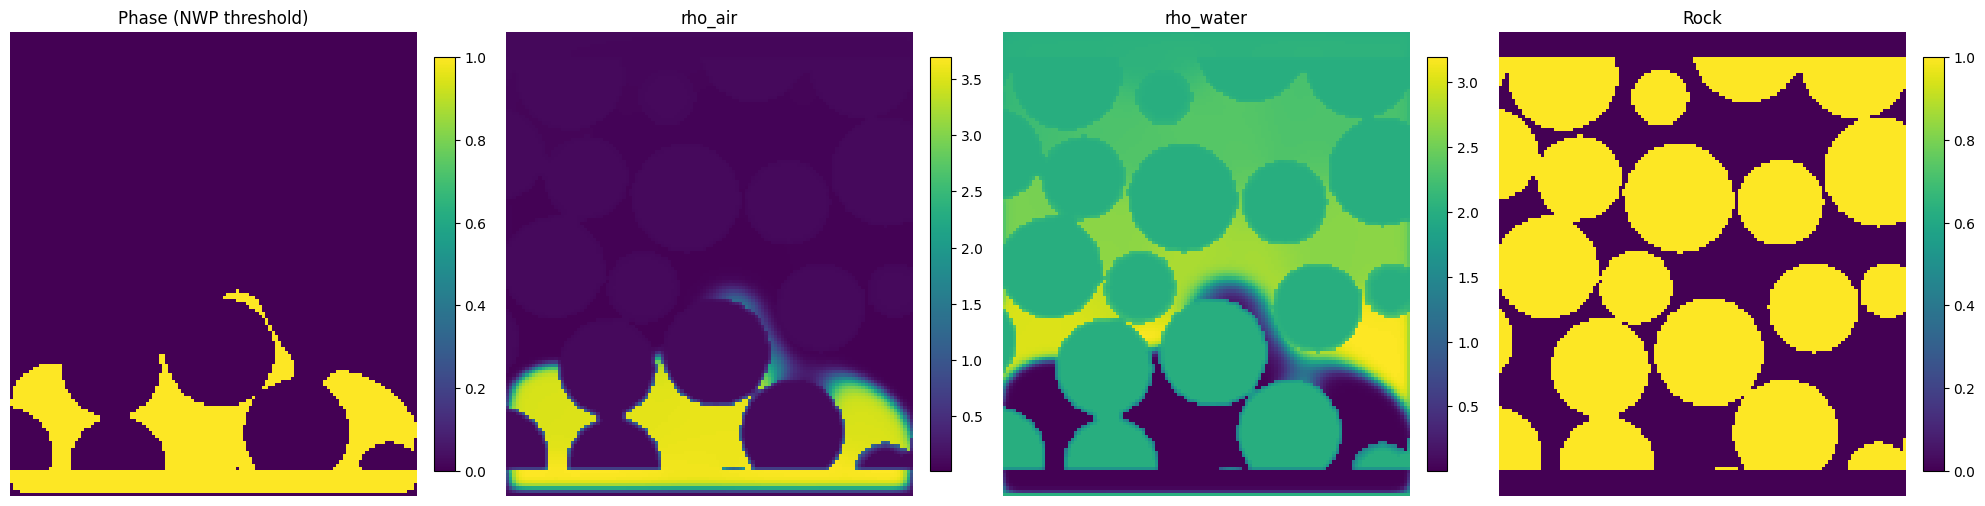

plotting for sample at ./128/output_drainage/data_0021000.vtk


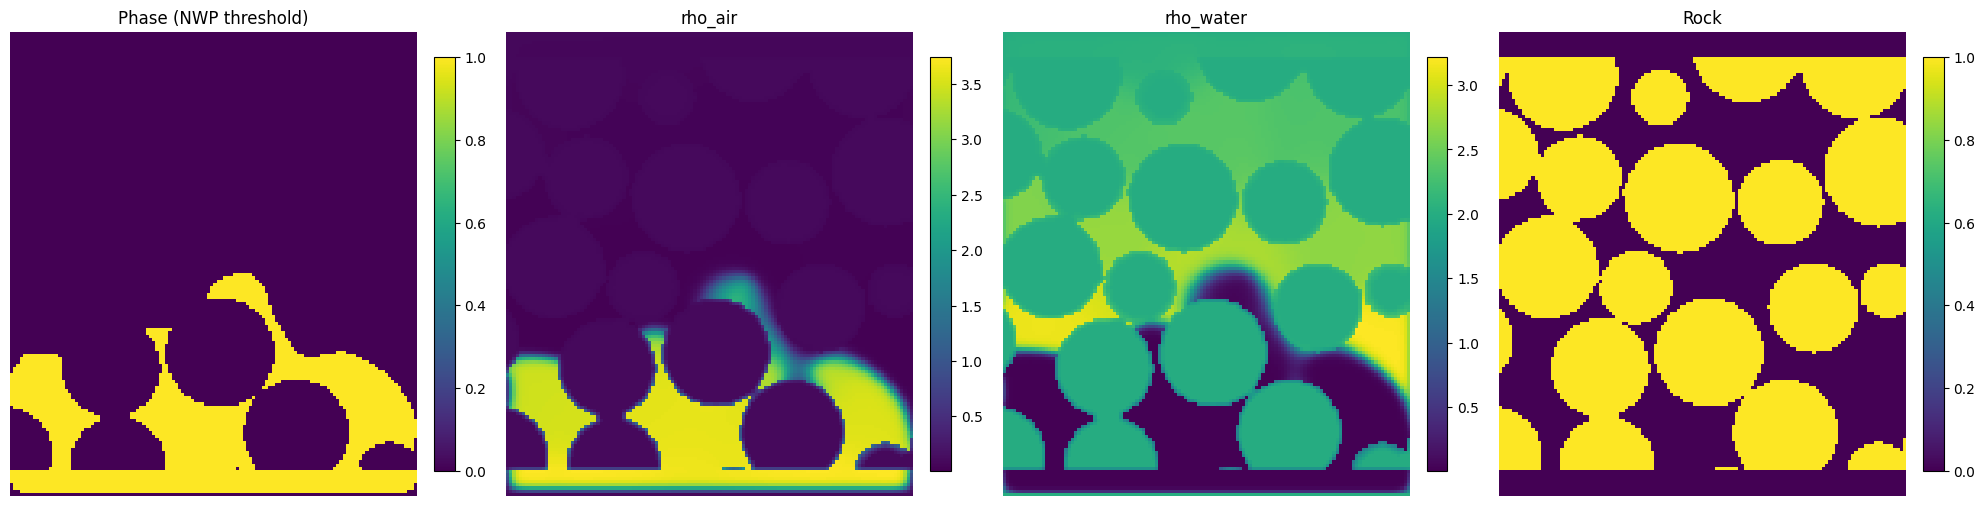

plotting for sample at ./128/output_drainage/data_0022000.vtk


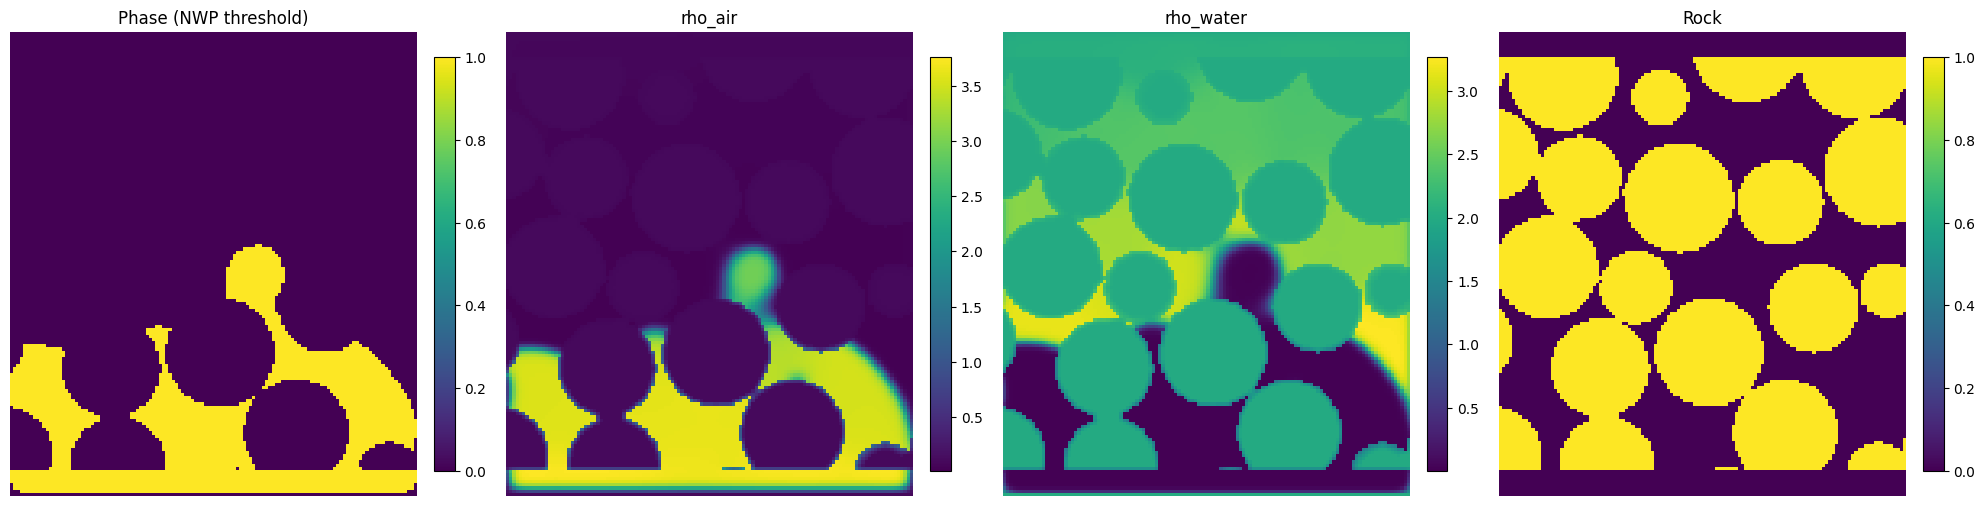

plotting for sample at ./128/output_drainage/data_0023000.vtk


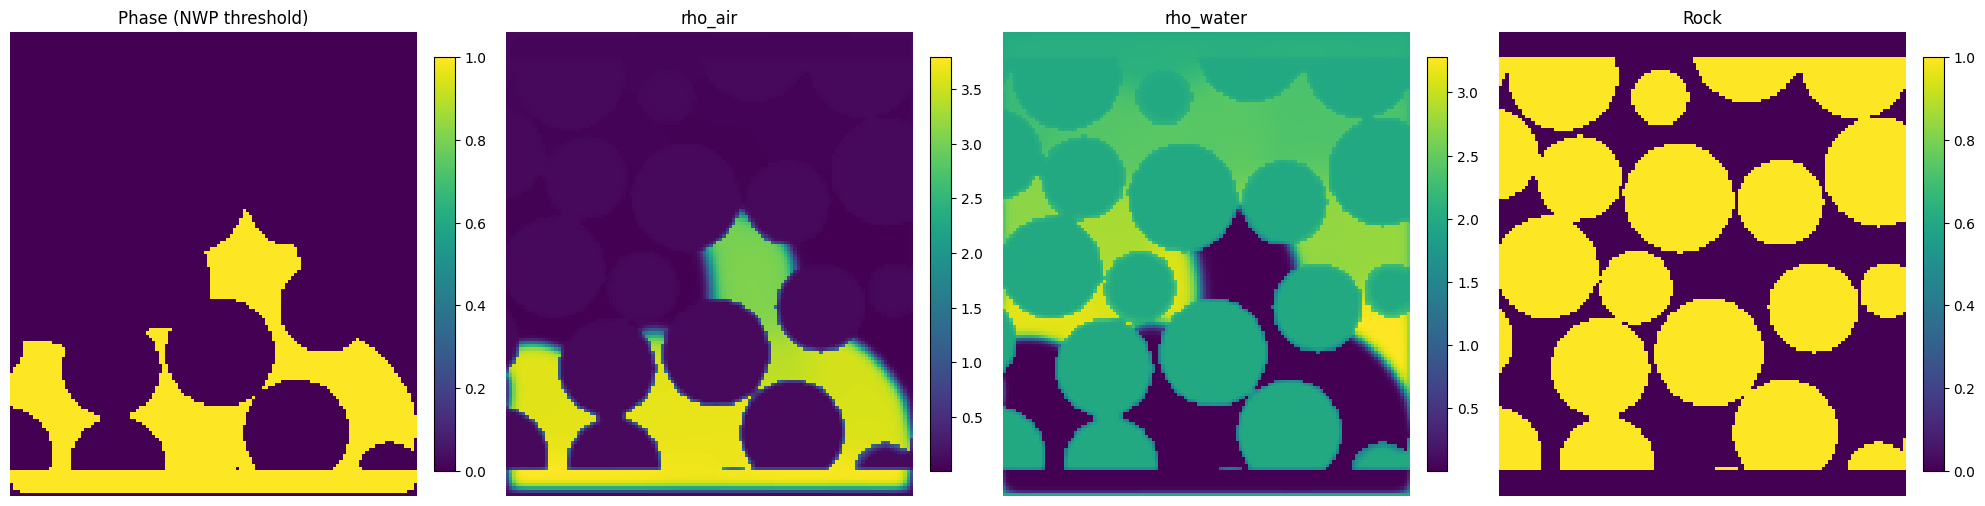

plotting for sample at ./128/output_drainage/data_0024000.vtk


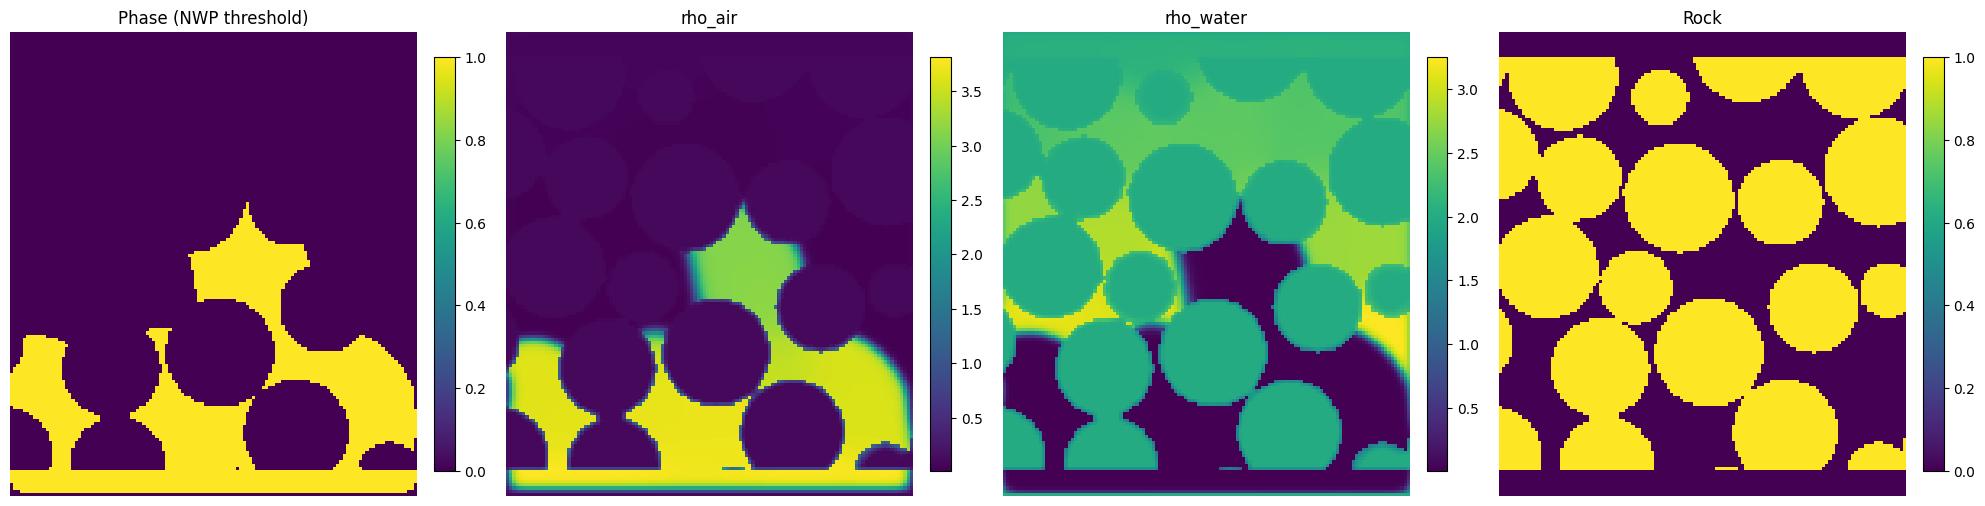

plotting for sample at ./128/output_drainage/data_0025000.vtk


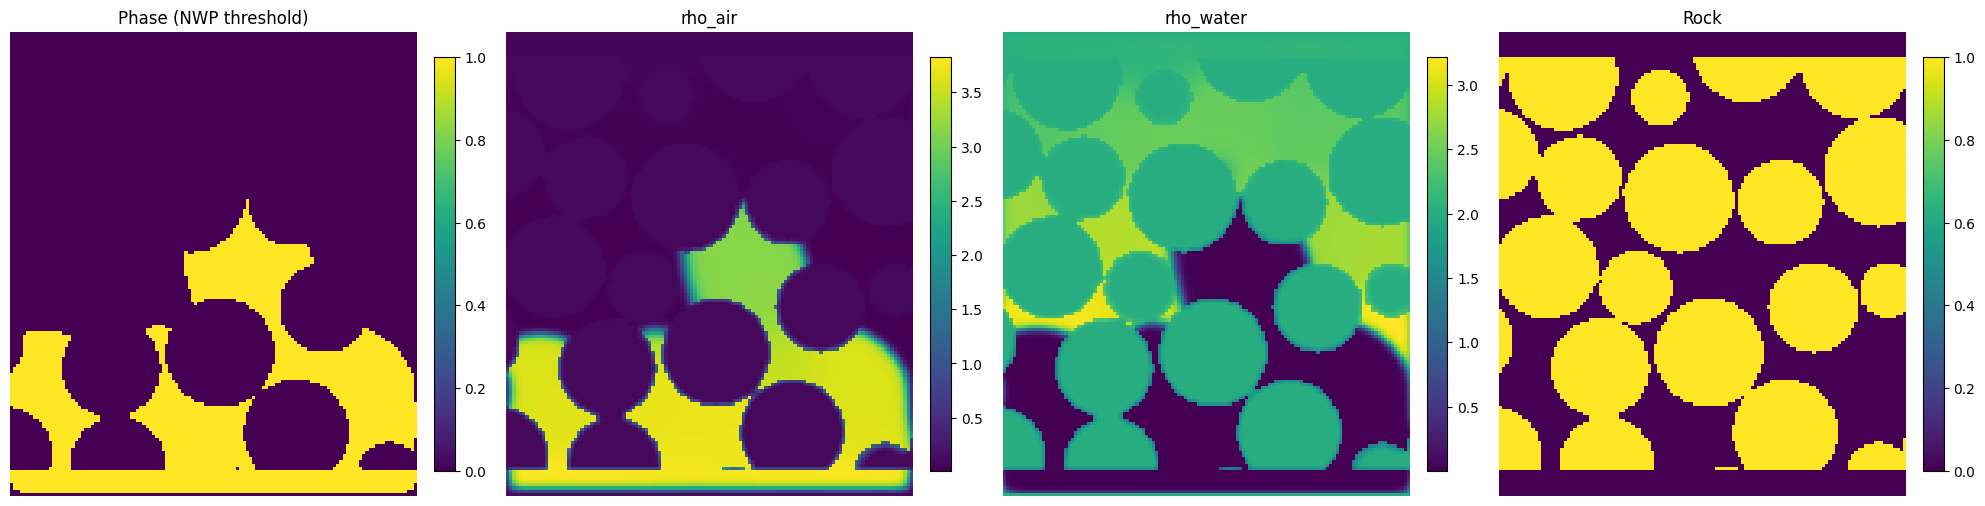

plotting for sample at ./128/output_drainage/data_0026000.vtk


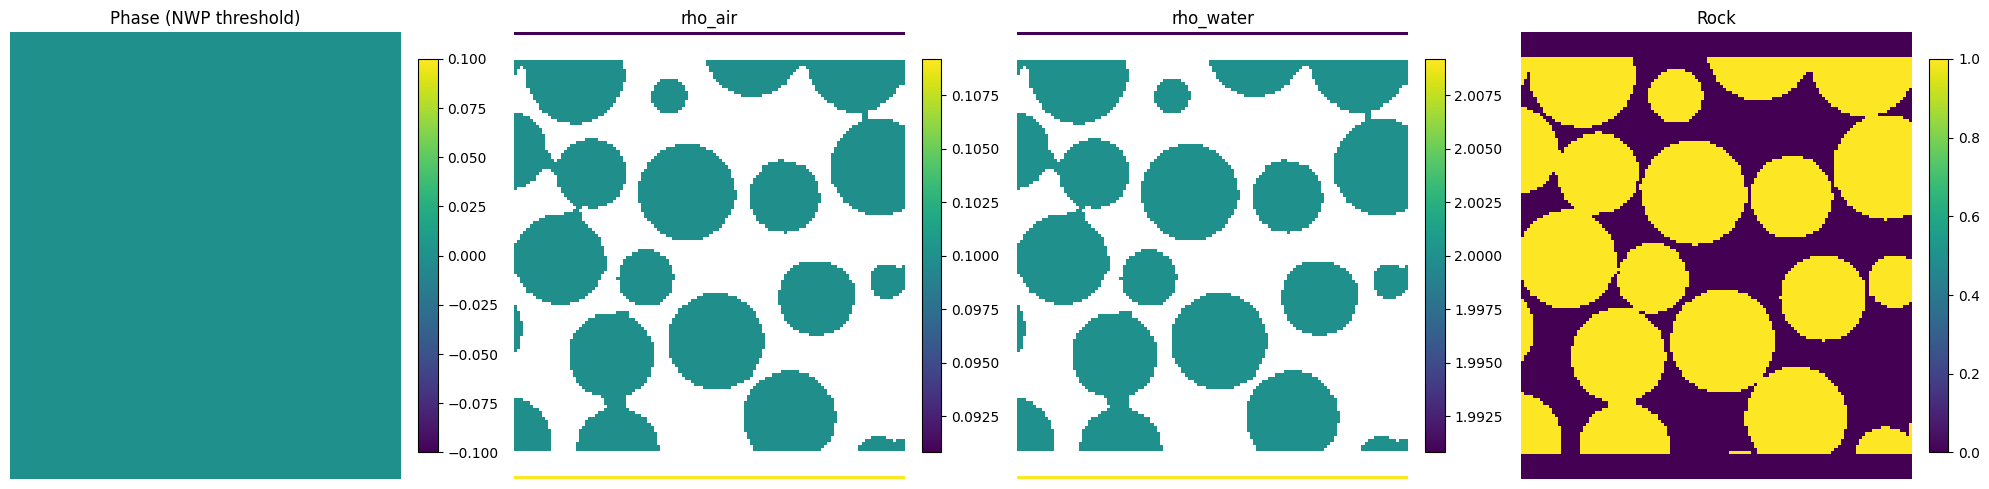

plotting for sample at ./128/output_drainage/data_0027000.vtk


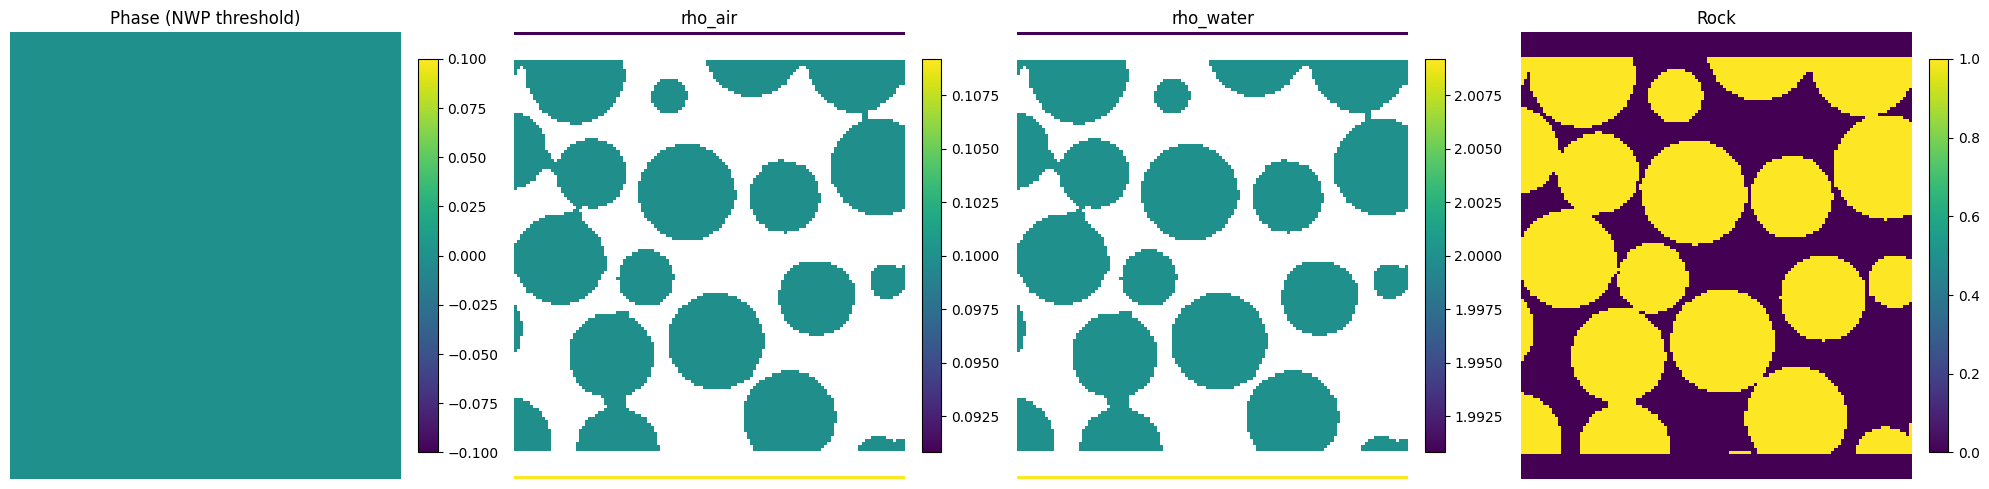

plotting for sample at ./128/output_drainage/data_0028000.vtk


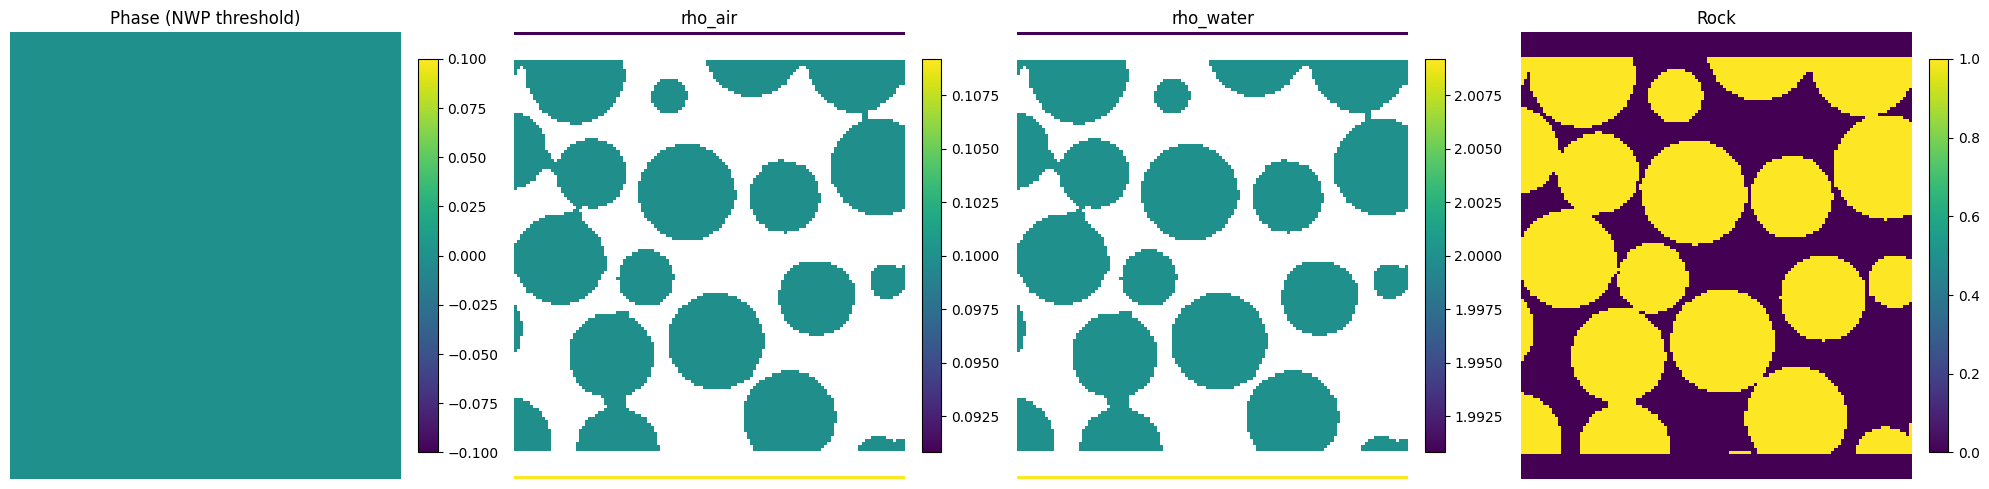

plotting for sample at ./128/output_drainage/data_0029000.vtk


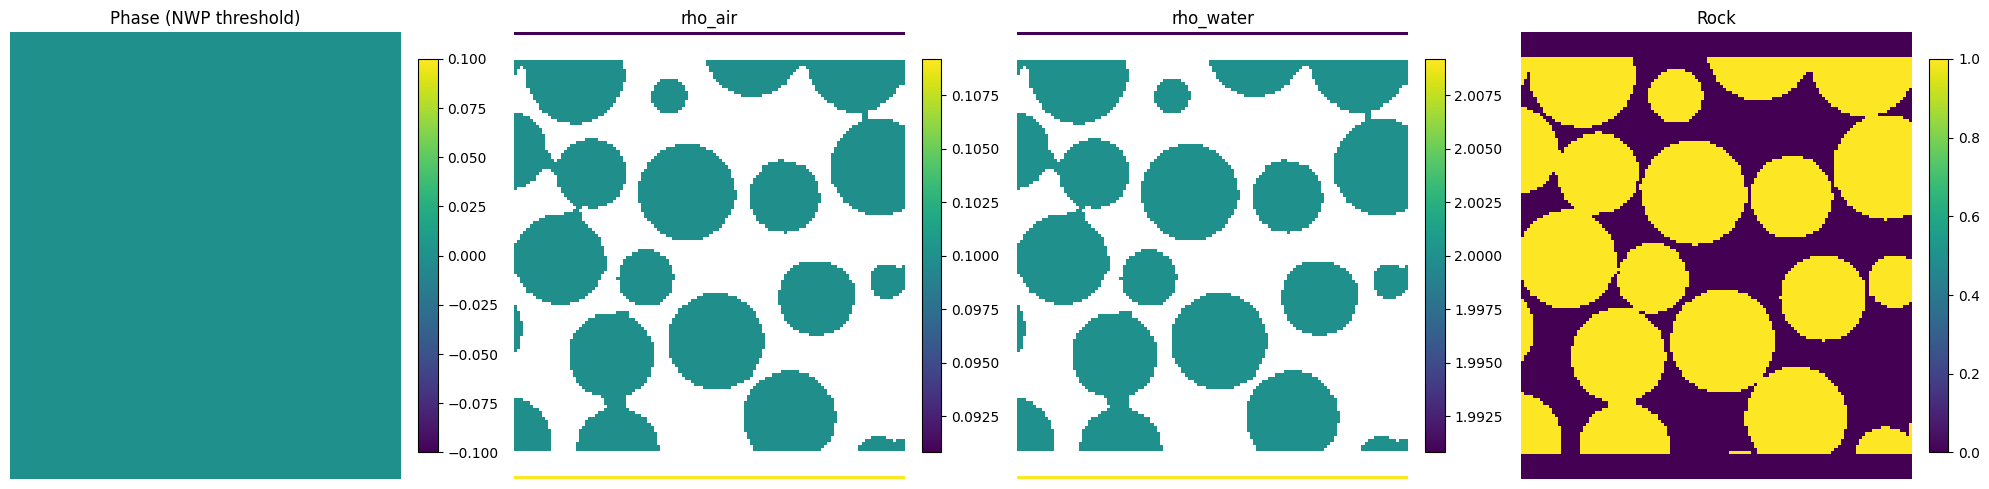

plotting for sample at ./128/output_drainage/data_0030000.vtk


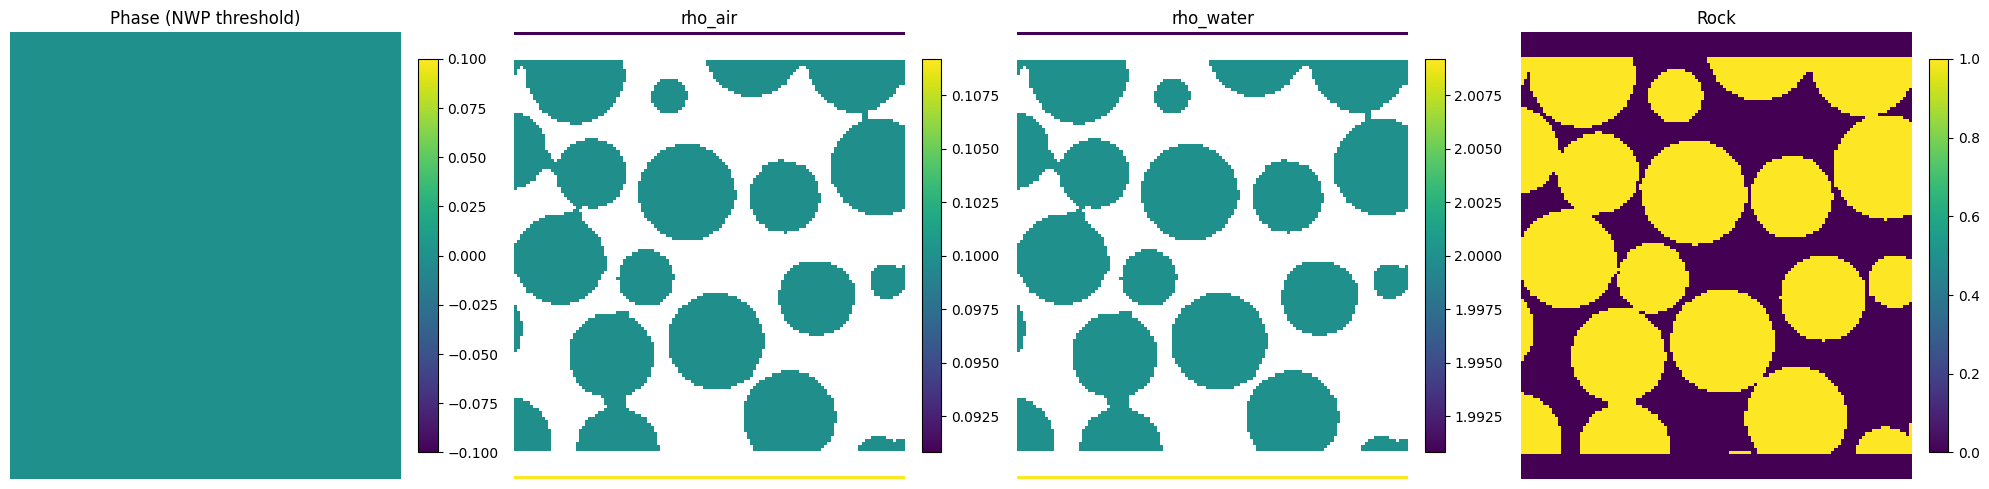

plotting for sample at ./128/output_drainage/data_0031000.vtk


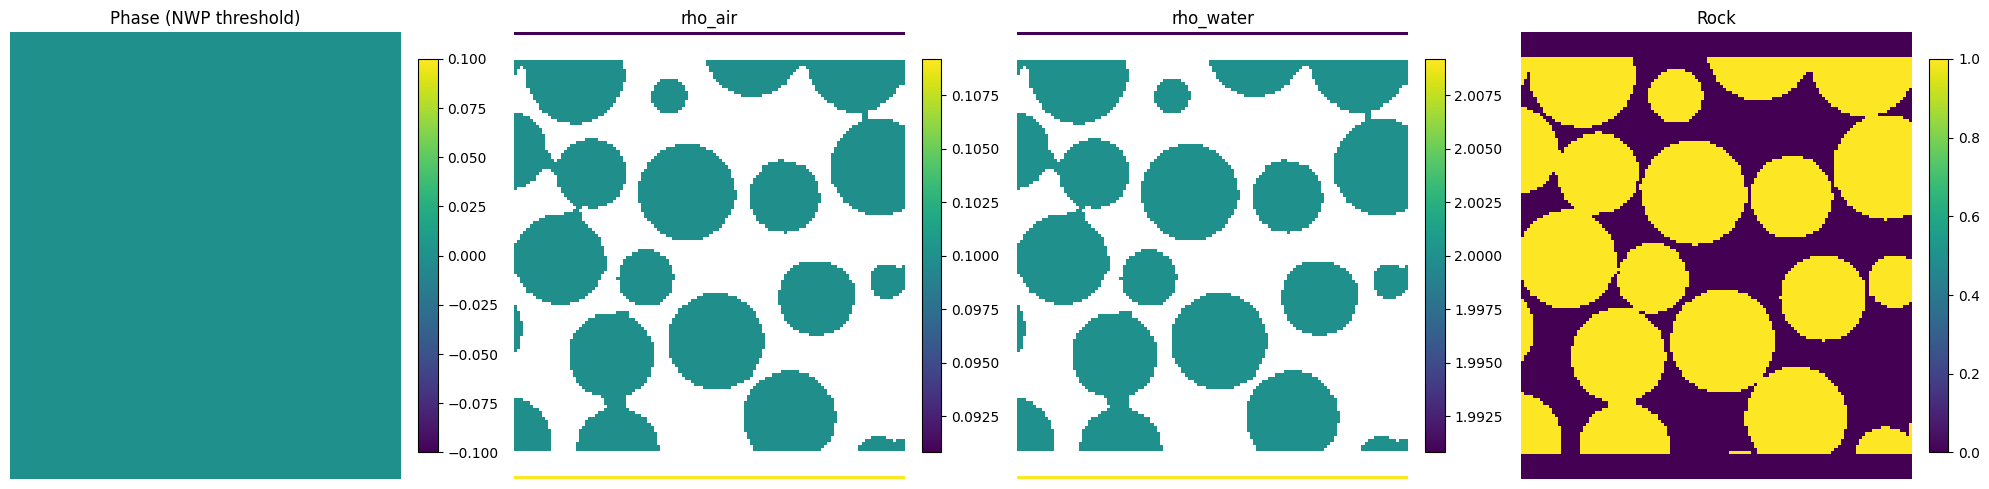

plotting for sample at ./128/output_drainage/data_0032000.vtk


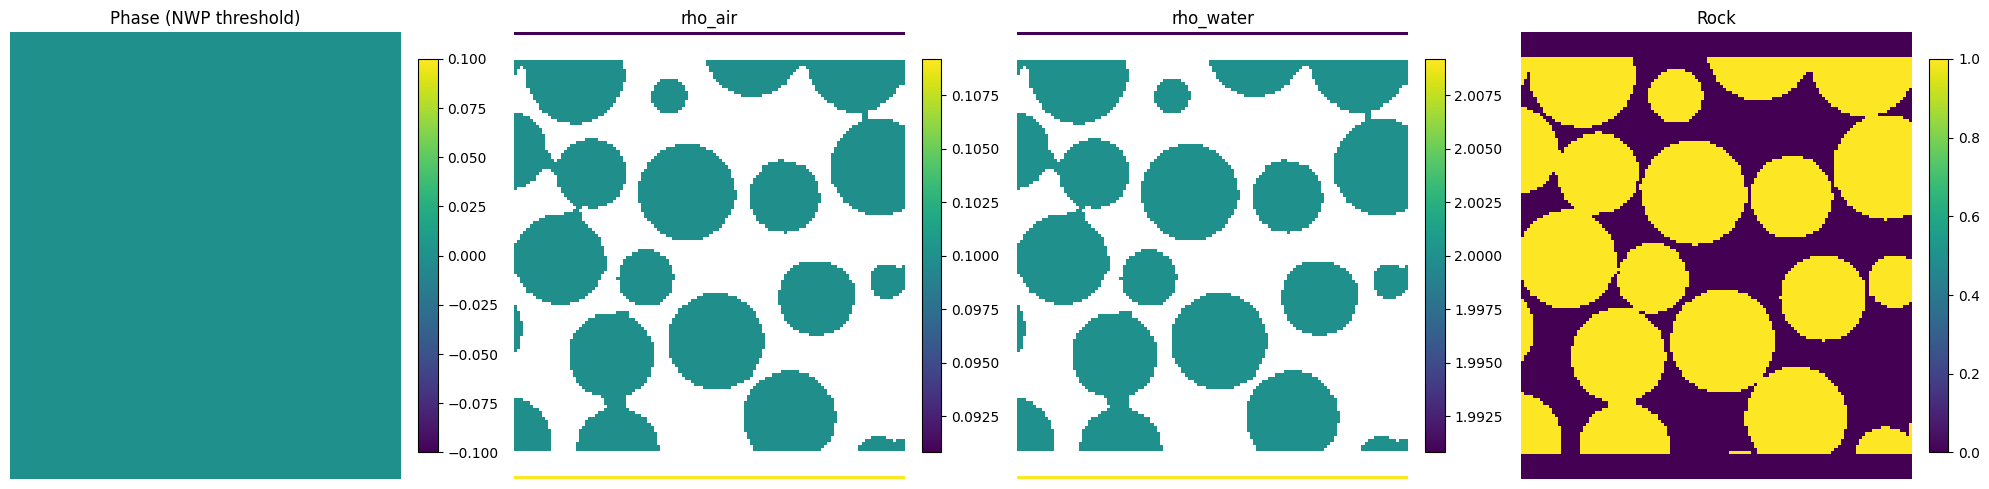

plotting for sample at ./128/output_drainage/data_0033000.vtk


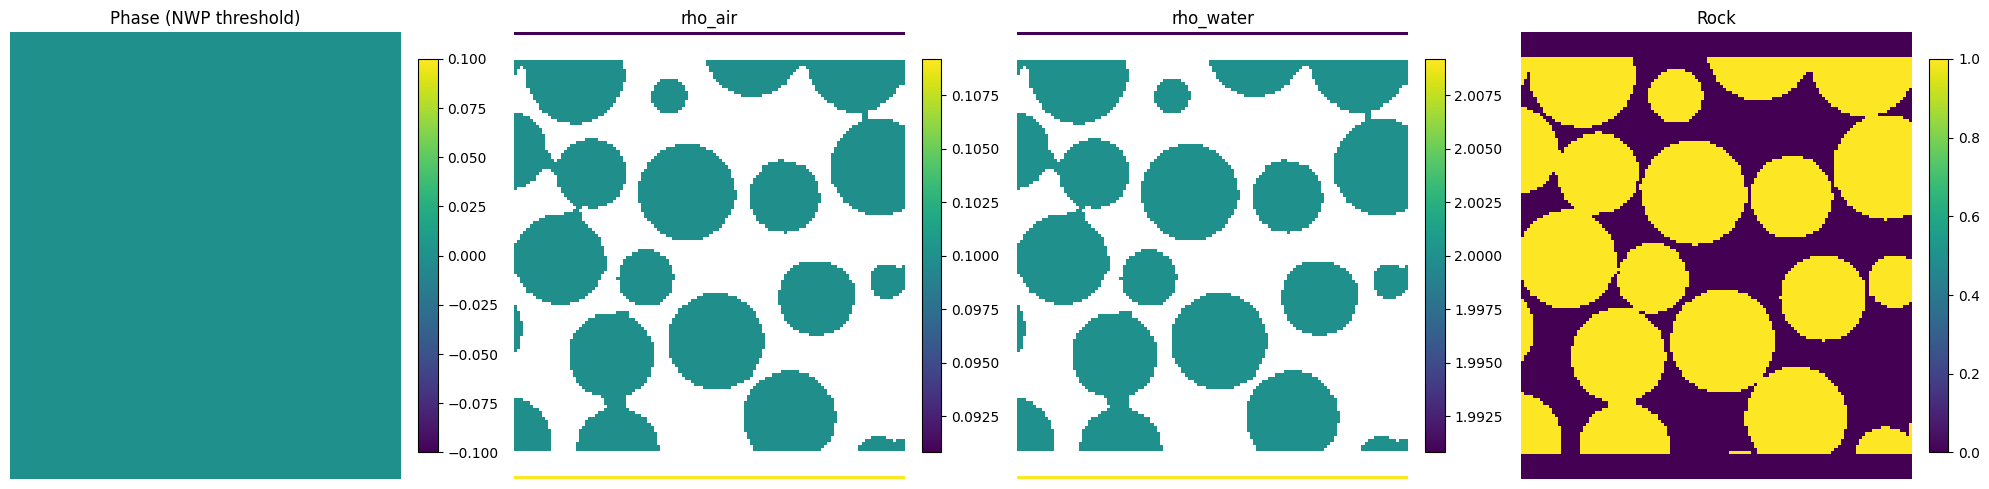

plotting for sample at ./128/output_drainage/data_0034000.vtk


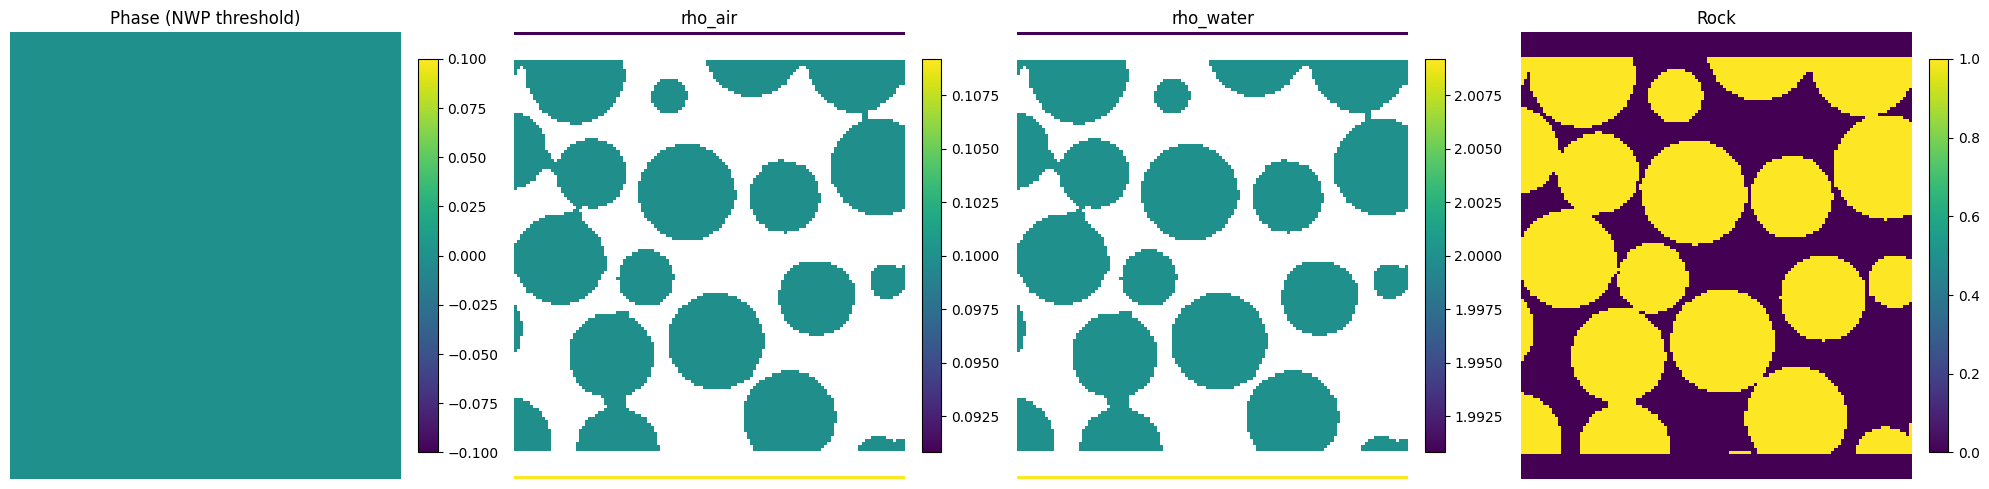

plotting for sample at ./128/output_drainage/data_0035000.vtk


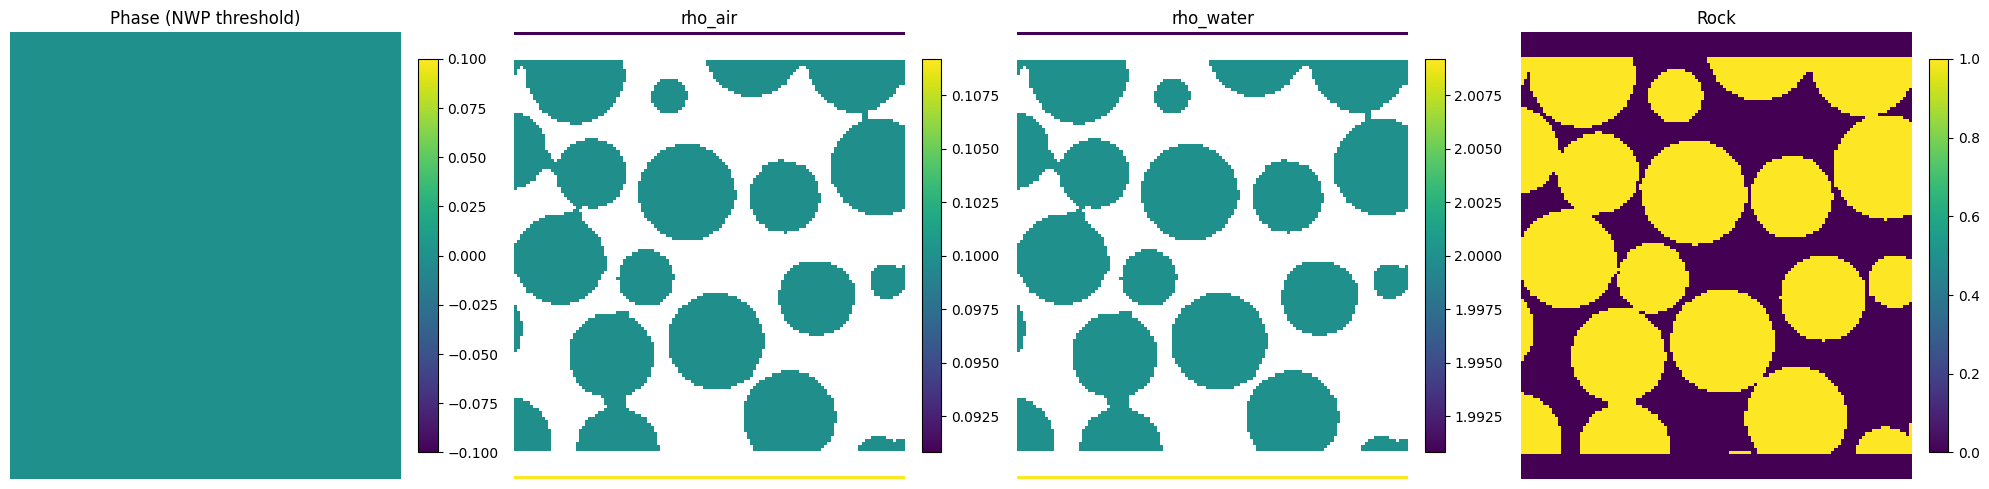

plotting for sample at ./128/output_drainage/data_0036000.vtk


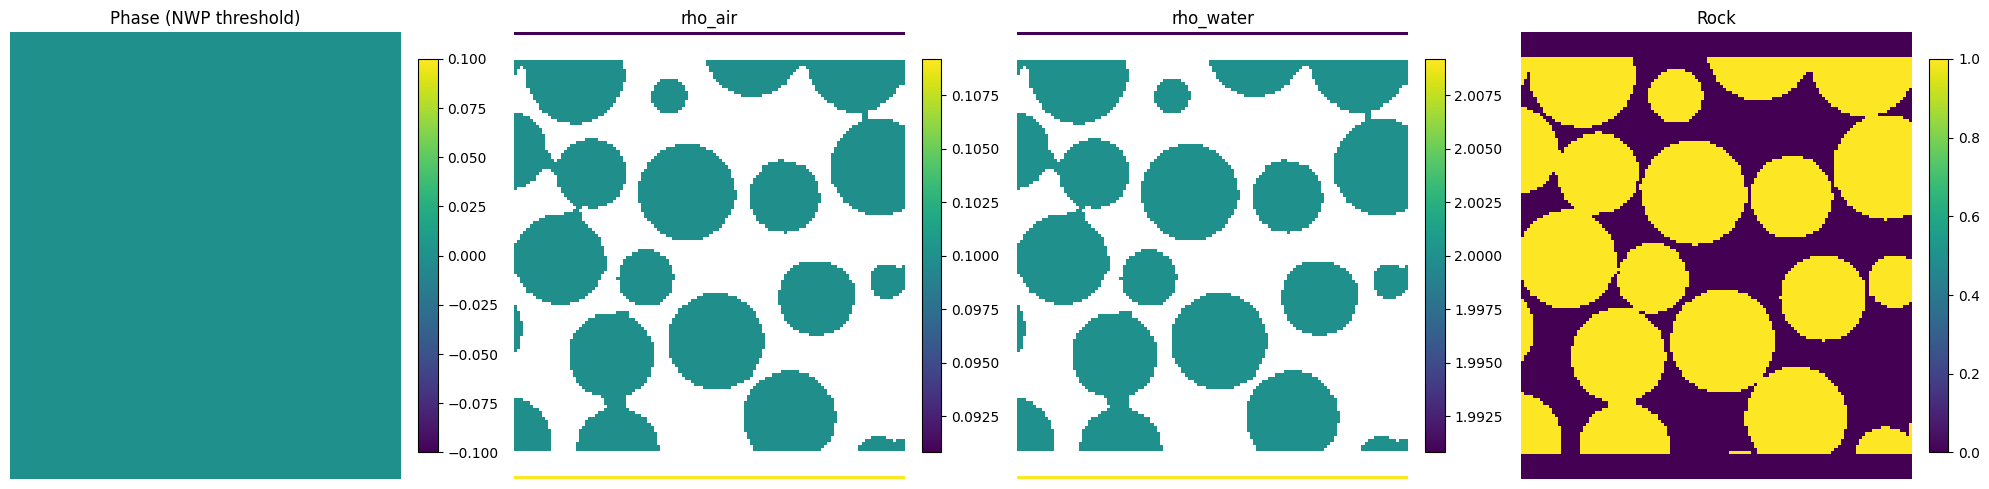

plotting for sample at ./128/output_drainage/data_0037000.vtk


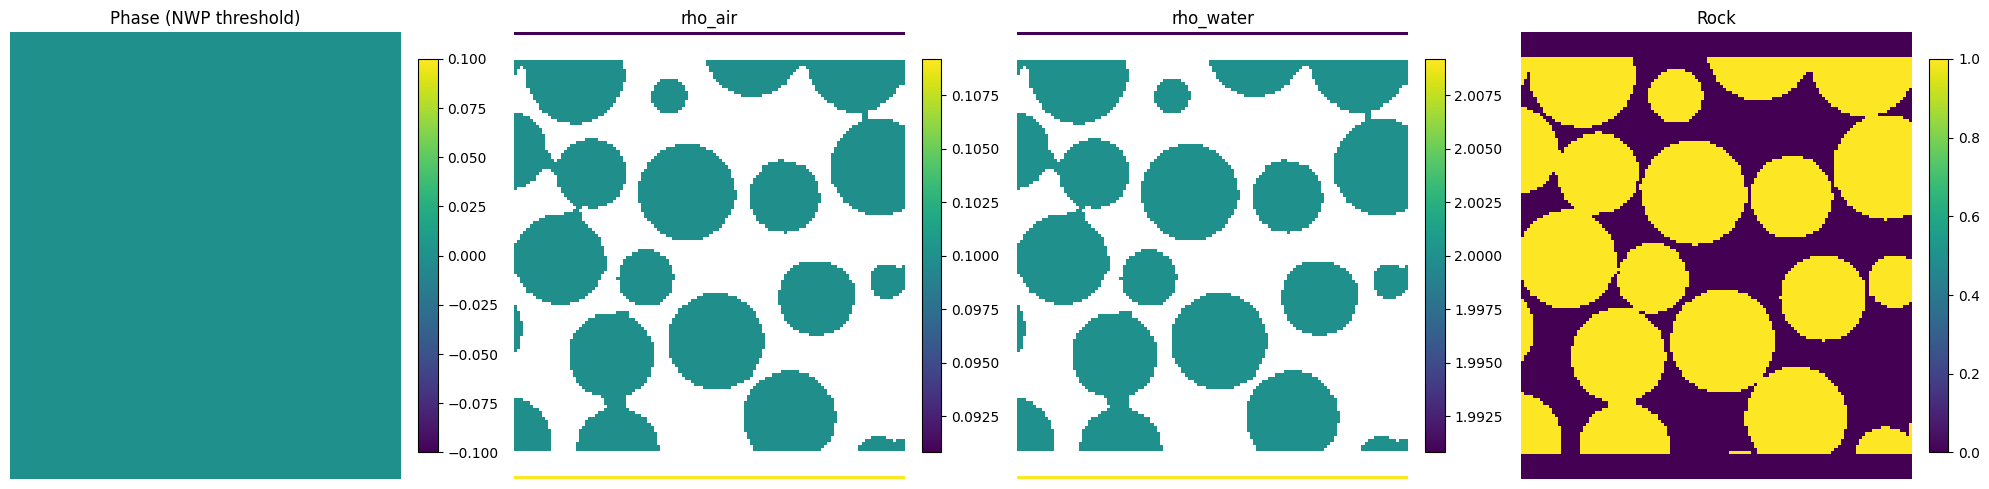

plotting for sample at ./128/output_drainage/data_0038000.vtk


KeyboardInterrupt: 

In [7]:
for i in range(50):
    idx = i
    print(f"plotting for sample at {out_sim[idx]}")
    sample = pv.read(out_sim[idx])
    plot_slice(sample, z=100)